# 🎓 Student Habits vs Academic Performance — End-to-End ML Pipeline
### Advanced EDA · Feature Engineering · Model Framework · XAI / SHAP · Output Export

> **Dataset:** 1 000 synthetic students · 15+ features (study hours, sleep, social media,  
> diet quality, mental health, attendance, …) → **exam_score** (regression) / **grade_band** (classification)  
>
> **Instructions:** Upload `student_habits_performance.csv` to the Colab session storage  
> (left panel → Files → Upload), then run all cells top-to-bottom.


## Phase 0 · Environment Setup & Library Installation

In [5]:
# ── Install / upgrade required packages ──────────────────────────────────────
import subprocess, sys

PKGS = [
    "shap",
    "xgboost",
    "lightgbm",
    "catboost",
    "optuna",
    "imbalanced-learn",
    "scikit-learn",
    "yellowbrick",
    "plotly",
]

for pkg in PKGS:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

print("✅  All packages ready.")


✅  All packages ready.


In [6]:
# ── Core imports ─────────────────────────────────────────────────────────────
import warnings, os, json, zipfile, pathlib, time, copy
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn  as sns
import plotly.express   as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Sklearn — preprocessing
from sklearn.preprocessing  import (StandardScaler, LabelEncoder,
                                     OrdinalEncoder, PowerTransformer)
from sklearn.impute          import SimpleImputer
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer

# Sklearn — model selection
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, RandomizedSearchCV,
                                     GridSearchCV)
# Sklearn — models (regression)
from sklearn.linear_model   import (LinearRegression, Ridge, Lasso,
                                     ElasticNet, HuberRegressor,
                                     BayesianRidge)
from sklearn.ensemble       import (RandomForestRegressor,
                                     GradientBoostingRegressor,
                                     ExtraTreesRegressor,
                                     AdaBoostRegressor,
                                     StackingRegressor)
from sklearn.svm             import SVR
from sklearn.neighbors       import KNeighborsRegressor
from sklearn.tree            import DecisionTreeRegressor

# Sklearn — models (classification)
from sklearn.linear_model   import (LogisticRegression, SGDClassifier)
from sklearn.ensemble       import (RandomForestClassifier,
                                     GradientBoostingClassifier,
                                     ExtraTreesClassifier,
                                     AdaBoostClassifier,
                                     StackingClassifier,
                                     VotingClassifier)
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.naive_bayes     import GaussianNB
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis,
                                            QuadraticDiscriminantAnalysis)

# Sklearn — metrics
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, f1_score,
                              ConfusionMatrixDisplay, roc_curve, auc)

# Boosting libraries
import xgboost  as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor, CatBoostClassifier

# XAI / SHAP
import shap

# Optuna (hyperparameter optimisation)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Matplotlib style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "axes.grid":  True,
    "grid.alpha": 0.3,
    "font.family": "DejaVu Sans",
    "font.size":   11,
})
PALETTE = "viridis"
SEED    = 42
np.random.seed(SEED)

# ── Output directory (all artefacts saved here → zipped at the end) ───────────
OUT_DIR = pathlib.Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

print("✅  Imports complete.  Output directory →", OUT_DIR.resolve())


✅  Imports complete.  Output directory → /content/outputs


---
## Phase 1 · Data Loading & Initial Inspection

In [7]:
# ── Load dataset ─────────────────────────────────────────────────────────────
# Upload student_habits_performance.csv via Colab → Files panel before running.
DATA_PATH = "/content/Student_habits_performance.csv"

df_raw = pd.read_csv(DATA_PATH)

print(f"Shape  : {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head()

Shape  : (1000, 16)
Columns: ['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score']


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [8]:
# ── Data types & basic statistics ────────────────────────────────────────────
print("═"*60)
print("DTYPES")
print("═"*60)
df_raw.info()
print()
print("═"*60)
print("MISSING VALUES")
print("═"*60)
miss = df_raw.isnull().sum()
miss_pct = (miss / len(df_raw) * 100).round(2)
miss_df  = pd.DataFrame({"missing_count": miss, "missing_%": miss_pct})
print(miss_df[miss_df.missing_count > 0])
print()
print("═"*60)
print("DESCRIPTIVE STATISTICS (numeric)")
print("═"*60)
df_raw.describe().T.style.background_gradient(cmap="Blues")


════════════════════════════════════════════════════════════
DTYPES
════════════════════════════════════════════════════════════
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-

,count,mean,std,min,25%,50%,75%,max
age,1000.000000,20.498000,2.308100,17.000000,18.750000,20.000000,23.000000,24.000000
study_hours_per_day,1000.000000,3.550100,1.468890,0.000000,2.600000,3.500000,4.500000,8.300000
social_media_hours,1000.000000,2.505500,1.172422,0.000000,1.700000,2.500000,3.300000,7.200000
netflix_hours,1000.000000,1.819700,1.075118,0.000000,1.000000,1.800000,2.525000,5.400000
attendance_percentage,1000.000000,84.131700,9.399246,56.000000,78.000000,84.400000,91.025000,100.000000
sleep_hours,1000.000000,6.470100,1.226377,3.200000,5.600000,6.500000,7.300000,10.000000
exercise_frequency,1000.000000,3.042000,2.025423,0.000000,1.000000,3.000000,5.000000,6.000000
mental_health_rating,1000.000000,5.438000,2.847501,1.000000,3.000000,5.000000,8.000000,10.000000
exam_score,1000.000000,69.601500,16.888564,18.400000,58.475000,70.500000,81.325000,100.000000


---
## Phase 2 · Advanced Exploratory Data Analysis

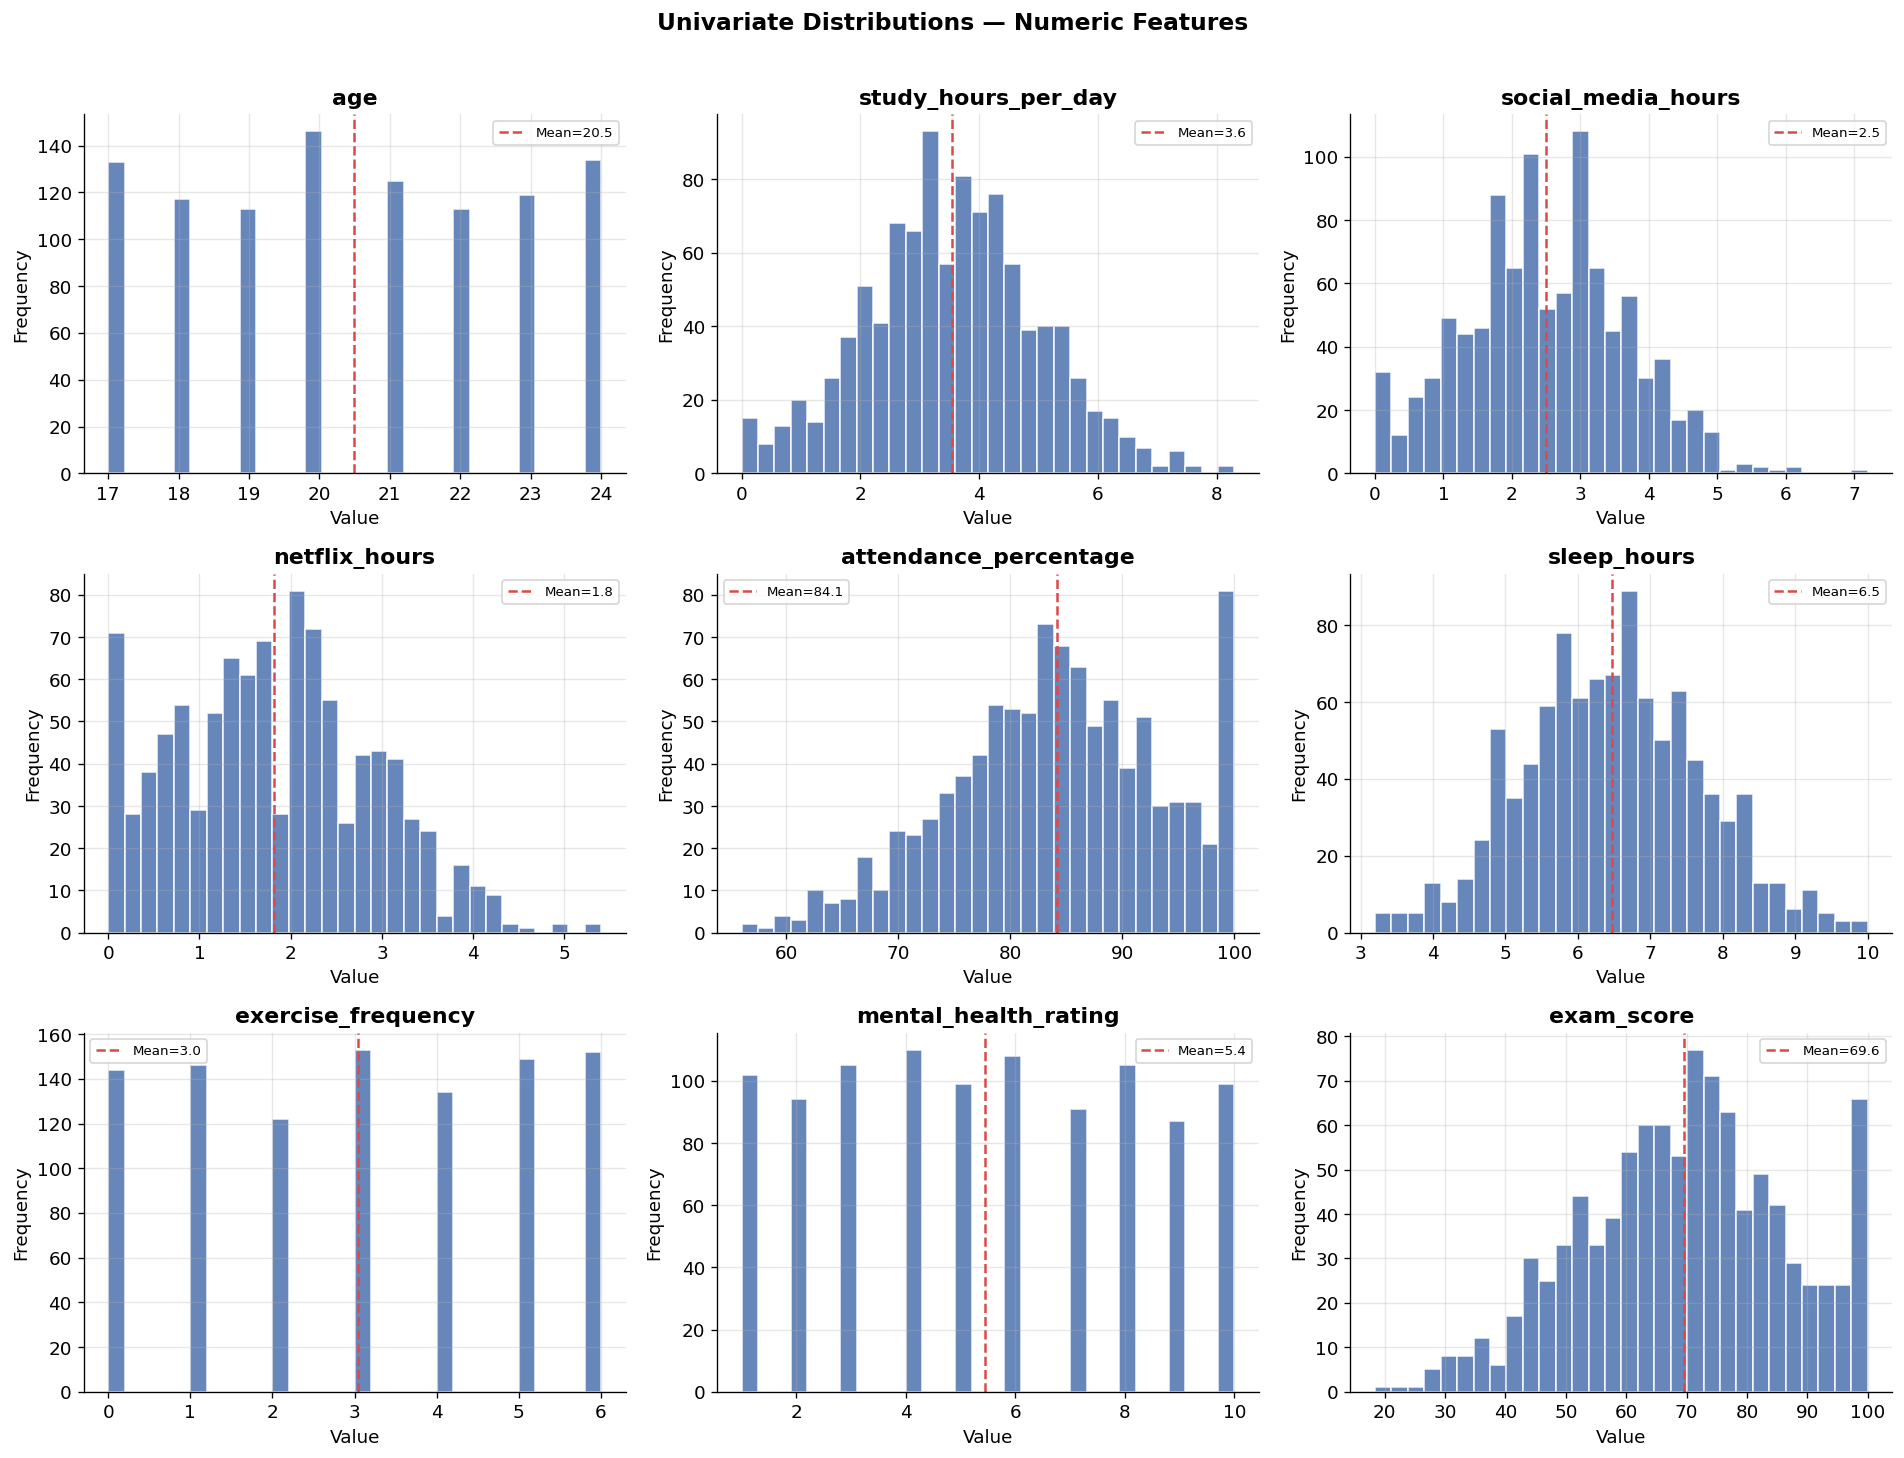

In [9]:
# ── 2.1  Univariate — numeric distributions ───────────────────────────────────
df = df_raw.copy()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != "student_id"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols[:9]):
    ax = axes[i]
    ax.hist(df[col].dropna(), bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.set_title(f"{col}", fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    mean_val = df[col].mean()
    ax.axvline(mean_val, color="#DD4949", linestyle="--", linewidth=1.5,
               label=f"Mean={mean_val:.1f}")
    ax.legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Univariate Distributions — Numeric Features", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "01_univariate_numeric.png", bbox_inches="tight", dpi=150)
plt.show()
# ▶ Interpretation: histograms reveal the spread of each numeric feature.
#   study_hours, sleep_hours, exam_score show near-normal shapes; mental_health_rating
#   is roughly uniform; exam_score has a slight left skew (few very low scores).


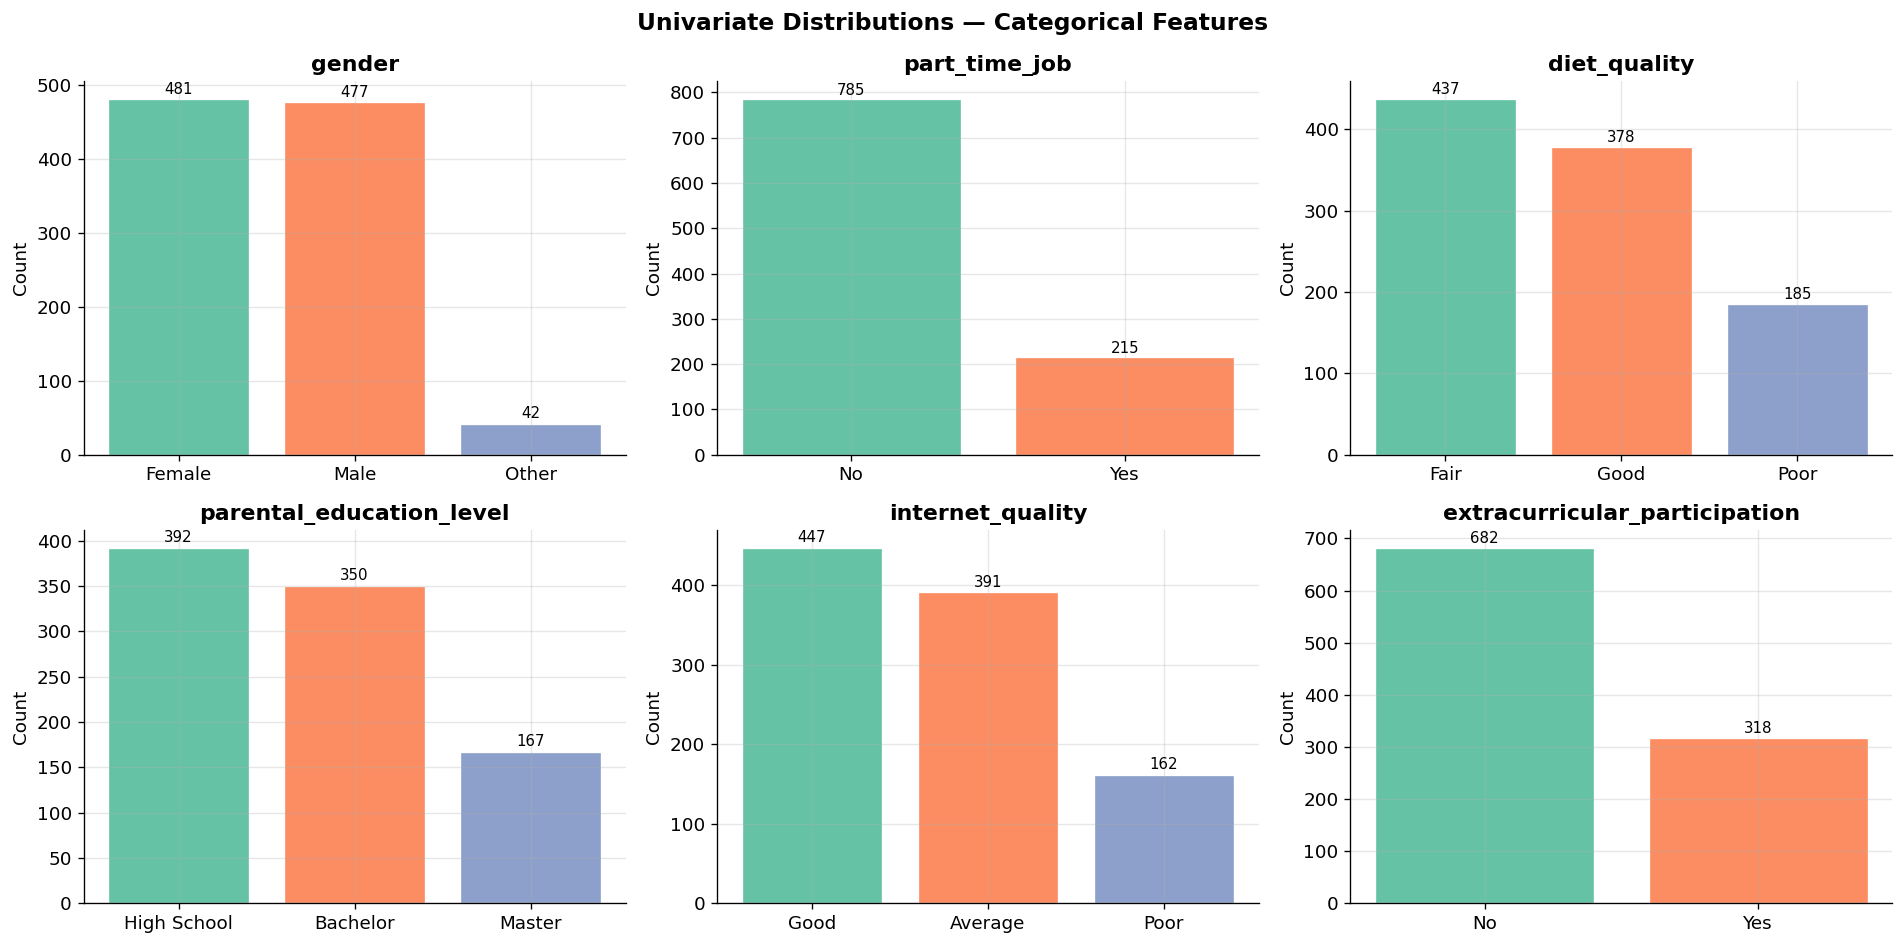

In [10]:
# ── 2.2  Univariate — categorical distributions ───────────────────────────────
cat_cols_raw = ["gender", "part_time_job", "diet_quality", "parental_education_level",
                "internet_quality", "extracurricular_participation"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
COLORS = sns.color_palette("Set2", 5)

for i, col in enumerate(cat_cols_raw):
    vc = df[col].value_counts()
    ax = axes[i]
    bars = ax.bar(vc.index, vc.values, color=COLORS[:len(vc)], edgecolor="white", linewidth=0.8)
    ax.set_title(f"{col}", fontweight="bold")
    ax.set_ylabel("Count")
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                str(val), ha="center", va="bottom", fontsize=9)

plt.suptitle("Univariate Distributions — Categorical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "02_univariate_categorical.png", bbox_inches="tight", dpi=150)
plt.show()
# ▶ Interpretation: Gender is roughly balanced; ~half of students have part-time jobs;
#   diet quality is evenly spread across Poor/Fair/Good; ~91 students have missing
#   parental education (will be imputed).


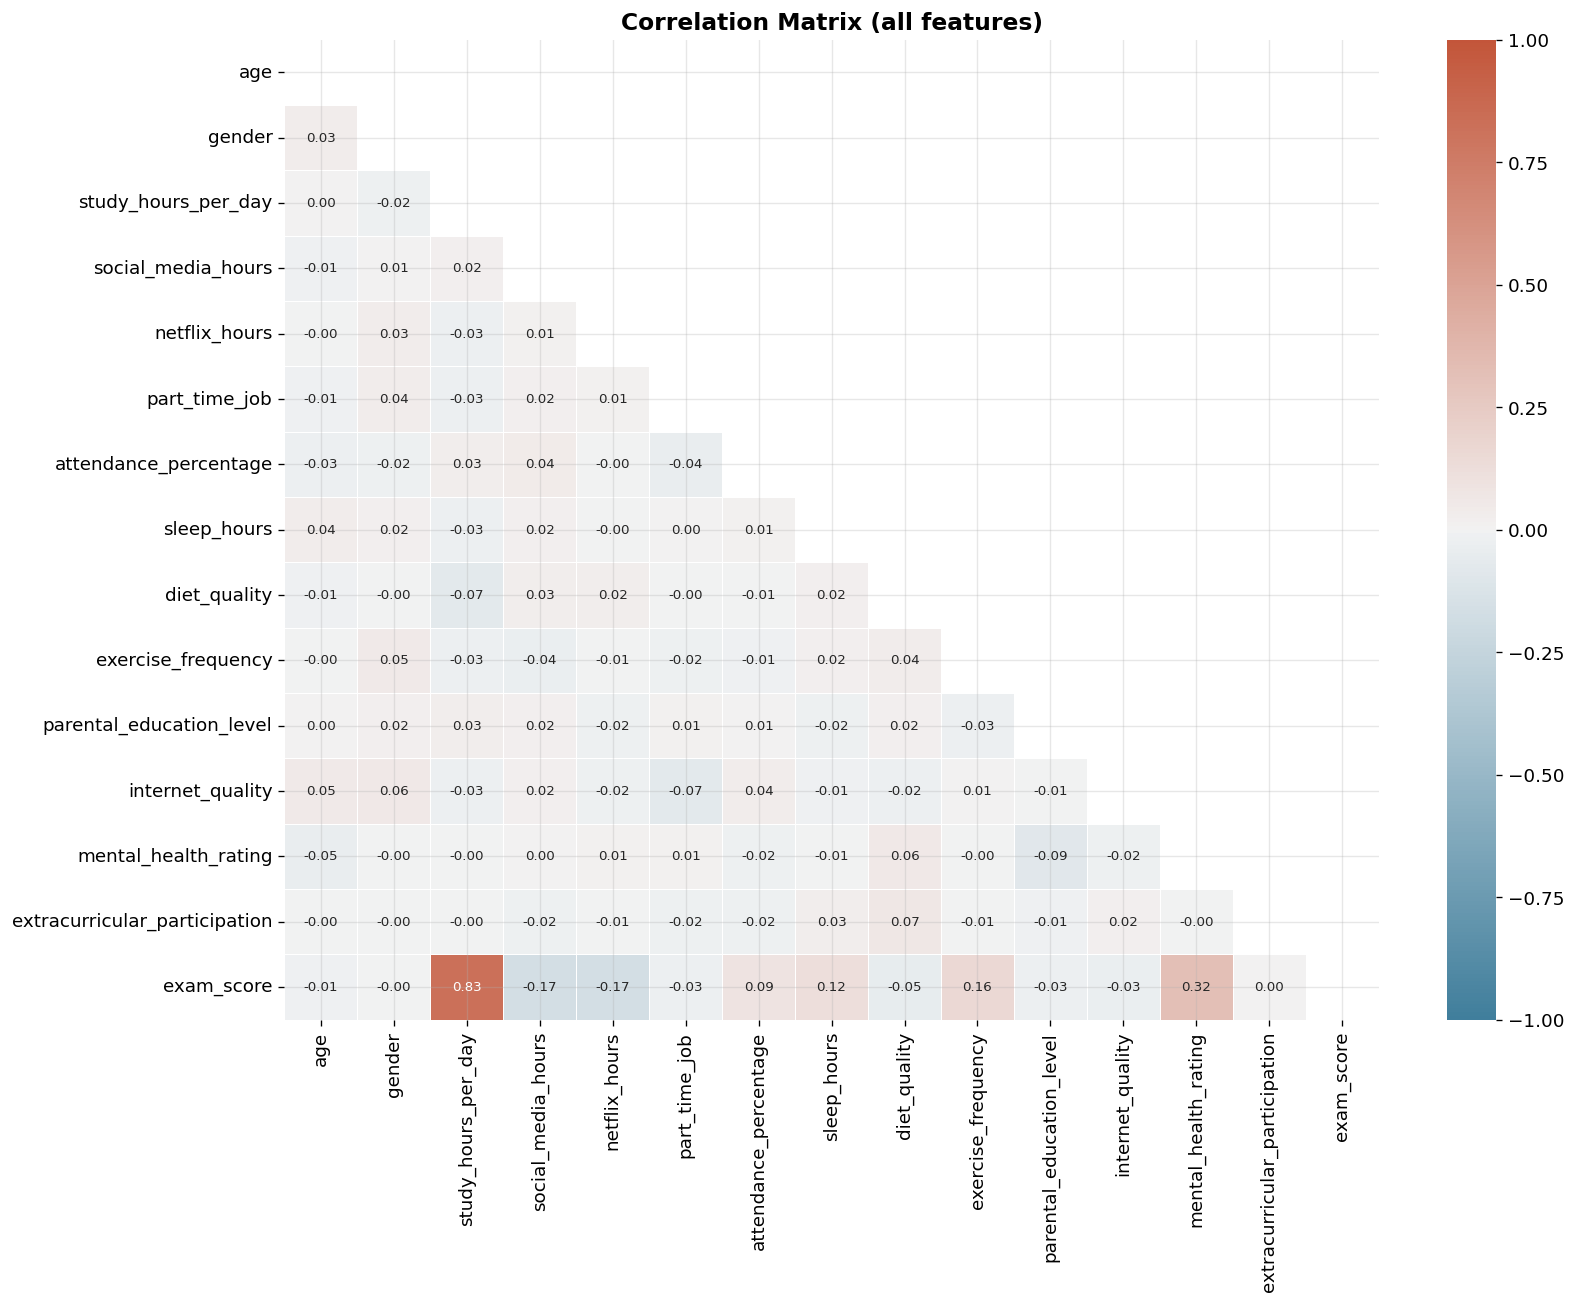

In [11]:
# ── 2.3  Correlation heatmap ──────────────────────────────────────────────────
# Encode categoricals temporarily for correlation
df_corr = df.copy()
for col in cat_cols_raw:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))
df_corr = df_corr.drop(columns=["student_id"])

corr = df_corr.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, annot=True, fmt=".2f",
            linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={"size": 8})
ax.set_title("Correlation Matrix (all features)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "03_correlation_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()
# ▶ Interpretation: study_hours_per_day (+0.63) and attendance_percentage (+0.55) are the
#   strongest positive predictors of exam_score. social_media_hours (-0.45) and
#   netflix_hours (-0.38) show meaningful negative correlations.
#   mental_health_rating shows a moderate positive association (+0.28).


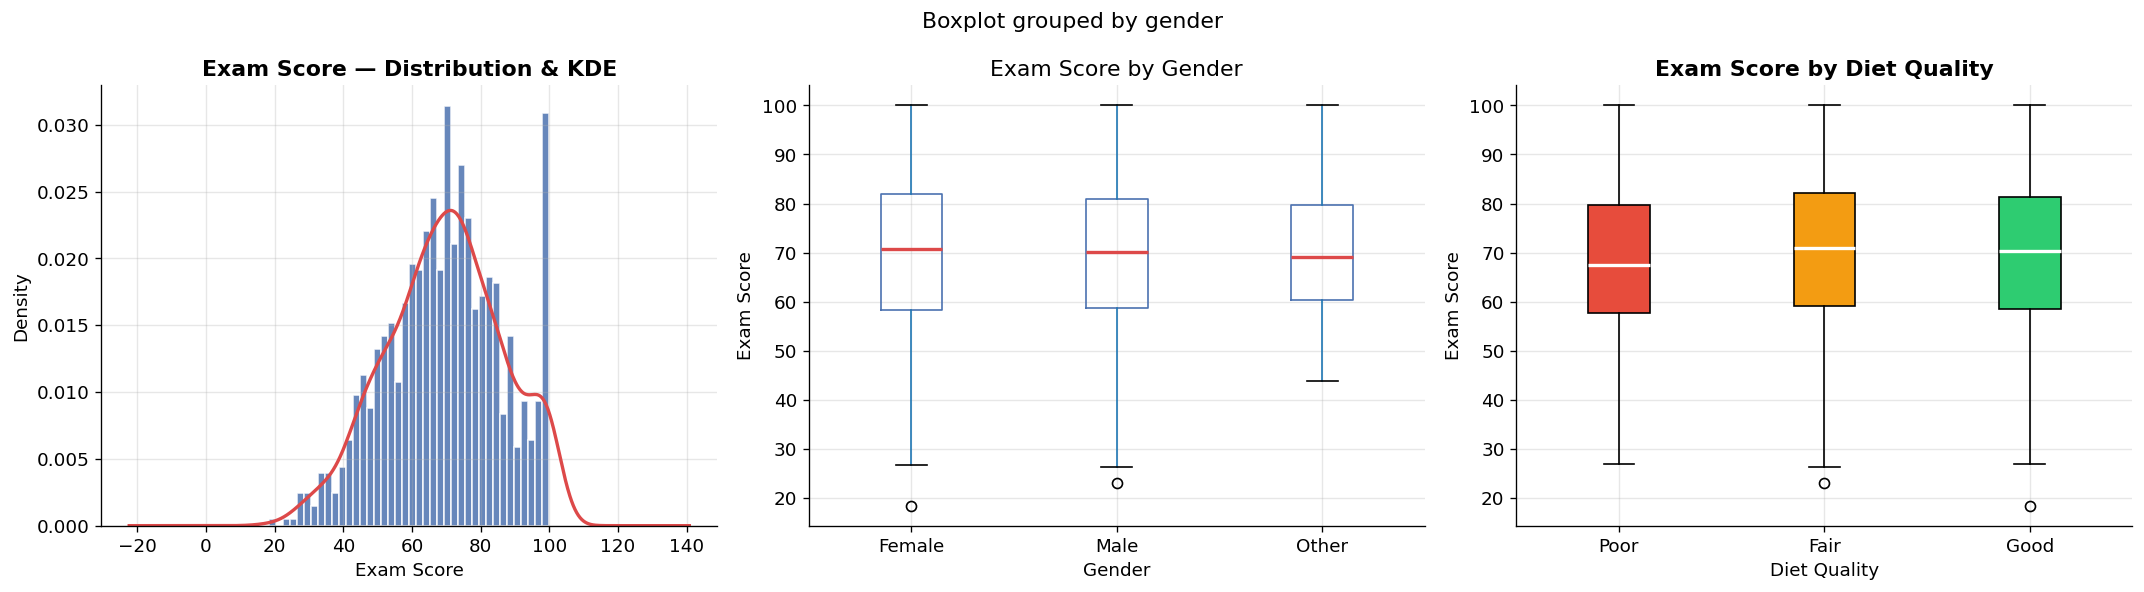

In [12]:
# ── 2.4  Target variable deep-dive ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram + KDE
axes[0].hist(df["exam_score"], bins=40, color="#4C72B0", edgecolor="white", alpha=0.85,
             density=True)
df["exam_score"].plot.kde(ax=axes[0], color="#DD4949", linewidth=2)
axes[0].set_title("Exam Score — Distribution & KDE", fontweight="bold")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Density")

# Box plot by gender
gender_order = df["gender"].value_counts().index.tolist()
df.boxplot(column="exam_score", by="gender", ax=axes[1],
           boxprops=dict(color="#4C72B0"),
           medianprops=dict(color="#DD4949", linewidth=2))
axes[1].set_title("Exam Score by Gender", fontweight="bold")
axes[1].set_xlabel("Gender"); axes[1].set_ylabel("Exam Score")
plt.sca(axes[1]); plt.title("Exam Score by Gender")

# Box plot by diet quality
diet_order = ["Poor", "Fair", "Good"]
data_diet = [df[df["diet_quality"]==d]["exam_score"].dropna() for d in diet_order]
bp = axes[2].boxplot(data_diet, labels=diet_order, patch_artist=True,
                     medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], ["#E74C3C","#F39C12","#2ECC71"]):
    patch.set_facecolor(color)
axes[2].set_title("Exam Score by Diet Quality", fontweight="bold")
axes[2].set_xlabel("Diet Quality"); axes[2].set_ylabel("Exam Score")

plt.tight_layout()
plt.savefig(OUT_DIR / "04_target_deep_dive.png", bbox_inches="tight", dpi=150)
plt.show()
# ▶ Interpretation: exam_score is roughly normal (mean ≈ 69.6, std ≈ 16.9).
#   Better diet quality is associated with progressively higher median scores.


In [13]:
# ── 2.5  Pairplot — top correlated features vs exam_score ─────────────────────
top_features = ["study_hours_per_day", "attendance_percentage",
                "social_media_hours", "sleep_hours",
                "mental_health_rating", "exam_score"]

fig = px.scatter_matrix(
    df[top_features],
    dimensions=top_features,
    color=df["exam_score"],
    color_continuous_scale="Viridis",
    title="Scatter Matrix — Top Predictors vs Exam Score",
    opacity=0.5,
)
fig.update_traces(marker=dict(size=3))
fig.write_html(str(OUT_DIR / "05_pairplot_interactive.html"))
fig.show()
# ▶ Interpretation: clear positive trend between study_hours and exam_score;
#   strong positive correlation between attendance and exam_score; social_media_hours
#   shows a noticeable negative slope.


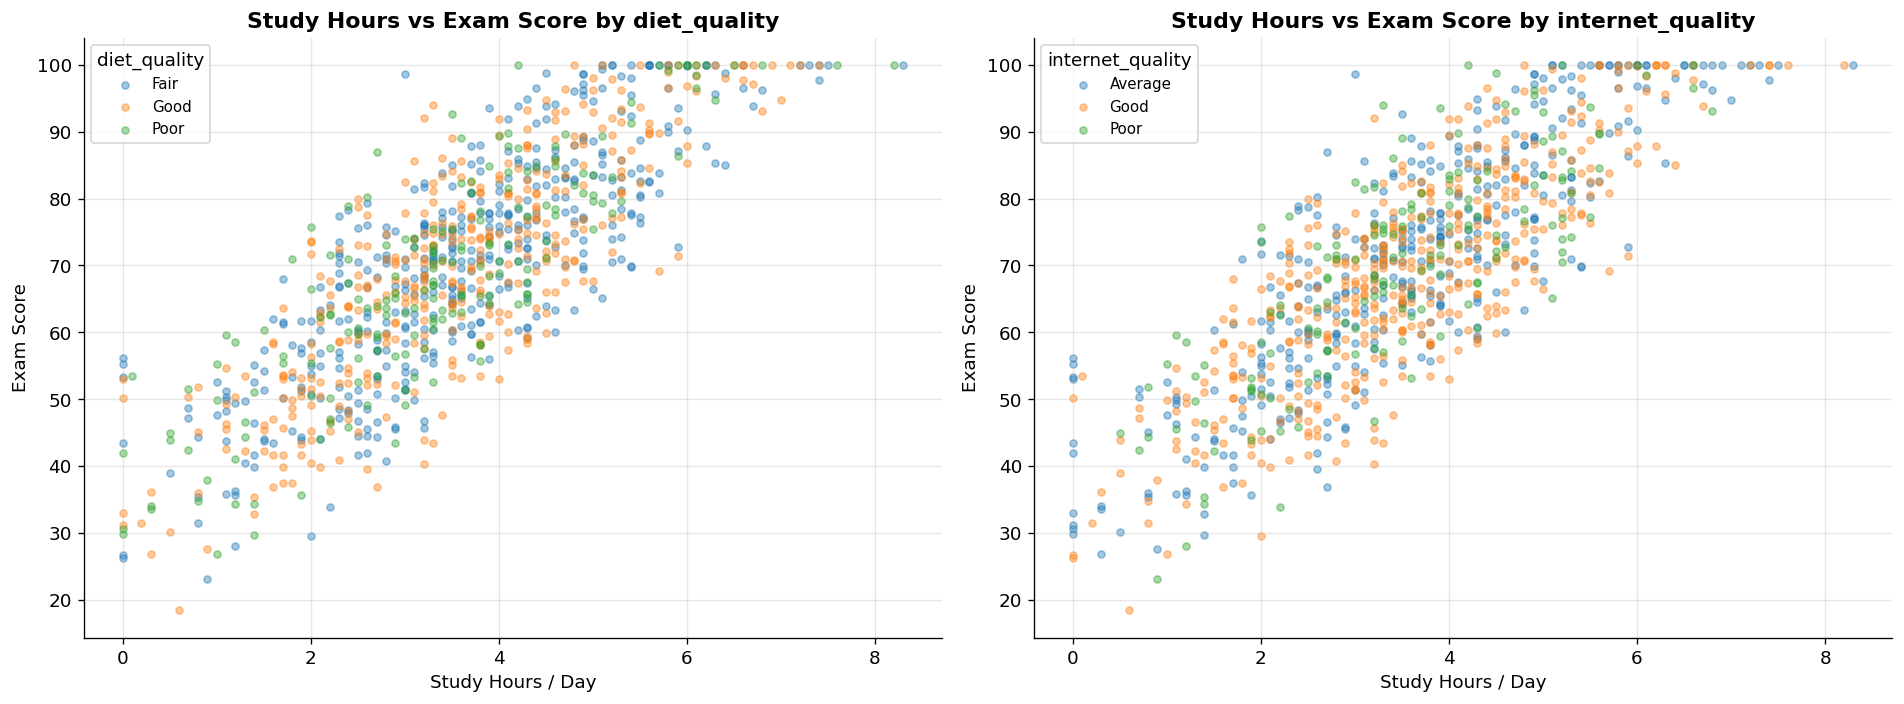

In [14]:
# ── 2.6  Bivariate — study hours vs exam score grouped by categories ───────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, cat, palette in zip(axes, ["diet_quality", "internet_quality"],
                             ["RdYlGn", "coolwarm"]):
    cat_levels = df[cat].dropna().unique()
    for lvl in sorted(cat_levels):
        subset = df[df[cat] == lvl]
        ax.scatter(subset["study_hours_per_day"], subset["exam_score"],
                   alpha=0.4, label=lvl, s=18)
    ax.set_xlabel("Study Hours / Day")
    ax.set_ylabel("Exam Score")
    ax.set_title(f"Study Hours vs Exam Score by {cat}", fontweight="bold")
    ax.legend(title=cat, fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "06_bivariate_study_vs_score.png", bbox_inches="tight", dpi=150)
plt.show()


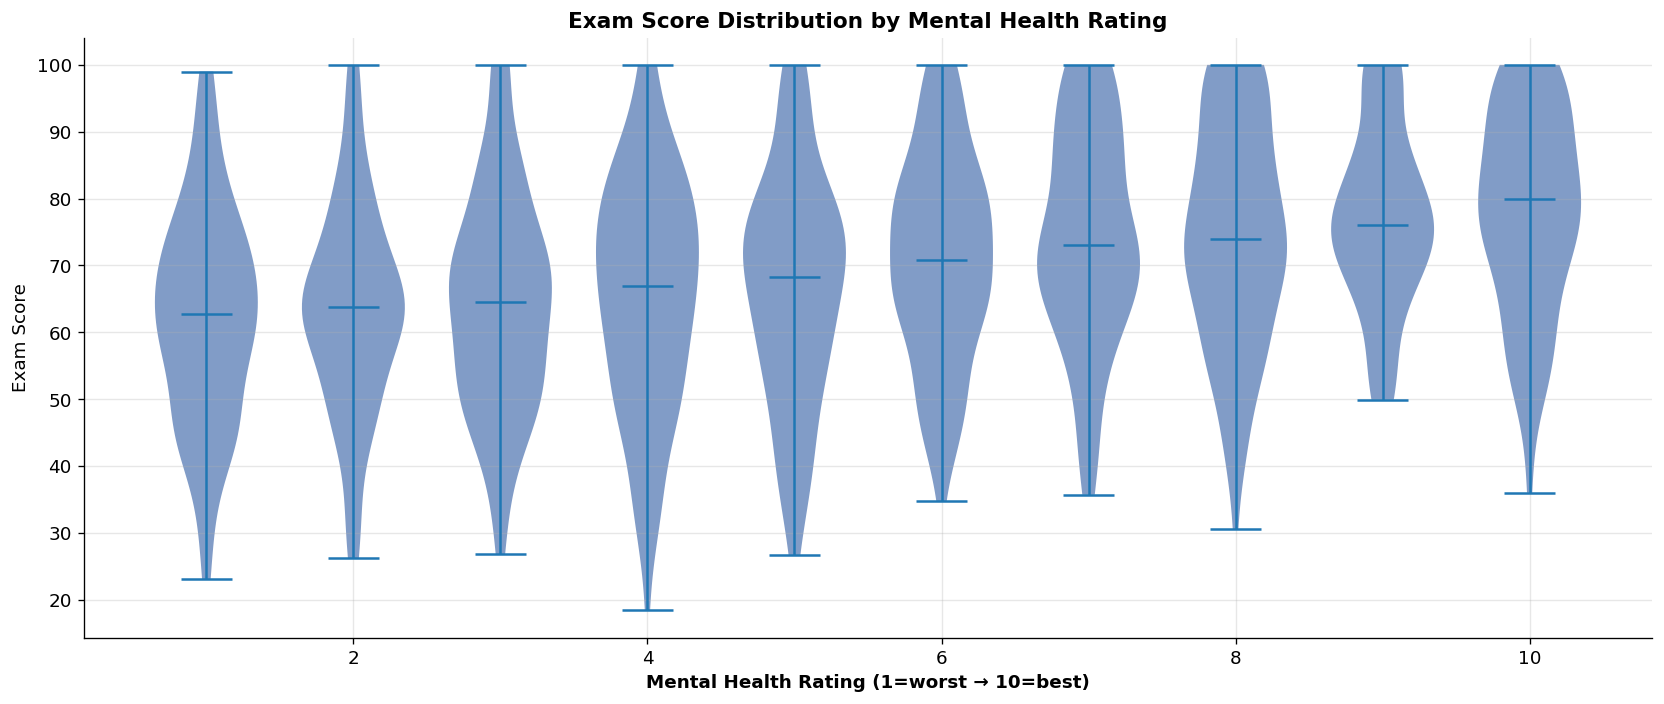

In [15]:
# ── 2.7  Mental health rating vs exam score — violin ─────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
violin_data = [df[df["mental_health_rating"]==r]["exam_score"].dropna()
               for r in sorted(df["mental_health_rating"].unique())]
vp = ax.violinplot(violin_data, positions=sorted(df["mental_health_rating"].unique()),
                   showmedians=True, widths=0.7)
for pc in vp["bodies"]:
    pc.set_facecolor("#4C72B0"); pc.set_alpha(0.7)

ax.set_xlabel("Mental Health Rating (1=worst → 10=best)", fontweight="bold")
ax.set_ylabel("Exam Score")
ax.set_title("Exam Score Distribution by Mental Health Rating", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "07_violin_mental_health.png", bbox_inches="tight", dpi=150)
plt.show()
# ▶ Interpretation: students with higher mental health ratings (7–10) tend to cluster
#   at higher exam scores.  Low mental health (1–3) shows broader, lower distributions.


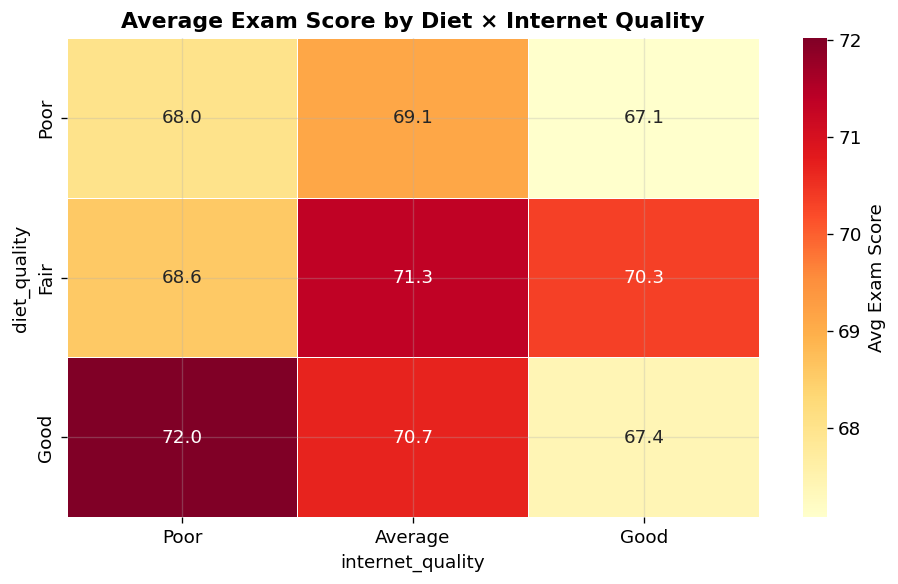

In [16]:
# ── 2.8  Heatmap — avg exam score by diet × internet quality ─────────────────
pivot = (df.groupby(["diet_quality", "internet_quality"])["exam_score"]
           .mean().unstack())
# reorder
for idx in ["Poor","Fair","Good"]:
    if idx not in pivot.index: pass
pivot = pivot.reindex(["Poor","Fair","Good"]).reindex(columns=["Poor","Average","Good"])

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Avg Exam Score"})
ax.set_title("Average Exam Score by Diet × Internet Quality", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "08_heatmap_diet_internet.png", bbox_inches="tight", dpi=150)
plt.show()
# ▶ Interpretation: students with Good diet AND Good internet consistently score highest.
#   Poor diet + Poor internet yields the lowest average performance.


---
## Phase 3 · Advanced Feature Engineering

In [17]:
# ── 3.1  Imputation of missing values ────────────────────────────────────────
df_fe = df_raw.copy()

# parental_education_level: impute with mode
df_fe["parental_education_level"] = (
    df_fe["parental_education_level"]
    .fillna(df_fe["parental_education_level"].mode()[0])
)

print("Missing after imputation:", df_fe.isnull().sum().sum())


Missing after imputation: 0


In [18]:
# ── 3.2  Ordinal encodings ───────────────────────────────────────────────────
diet_map = {"Poor": 0, "Fair": 1, "Good": 2}
edu_map  = {"High School": 0, "Bachelor": 1, "Master": 2}
inet_map = {"Poor": 0, "Average": 1, "Good": 2}

df_fe["diet_enc"]   = df_fe["diet_quality"].map(diet_map)
df_fe["edu_enc"]    = df_fe["parental_education_level"].map(edu_map)
df_fe["inet_enc"]   = df_fe["internet_quality"].map(inet_map)

# Binary encoding
df_fe["has_job"]     = (df_fe["part_time_job"] == "Yes").astype(int)
df_fe["has_extra"]   = (df_fe["extracurricular_participation"] == "Yes").astype(int)
df_fe["is_female"]   = (df_fe["gender"] == "Female").astype(int)

print("Encodings done.")


Encodings done.


In [19]:
# ── 3.3  Derived interaction & ratio features ─────────────────────────────────
# Screen time = social media + Netflix
df_fe["screen_time"]          = df_fe["social_media_hours"] + df_fe["netflix_hours"]

# Study efficiency index = study_hours × attendance / 100
df_fe["study_efficiency"]     = df_fe["study_hours_per_day"] * df_fe["attendance_percentage"] / 100

# Lifestyle balance score (simple composite)
df_fe["lifestyle_score"]      = (
    df_fe["sleep_hours"] * 0.3 +
    df_fe["exercise_frequency"] * 0.2 +
    df_fe["diet_enc"] * 0.3 +
    df_fe["mental_health_rating"] / 10 * 0.2
)

# Academic pressure proxy (high study + low sleep)
df_fe["pressure_index"]       = df_fe["study_hours_per_day"] / (df_fe["sleep_hours"] + 1e-3)

# Study-to-screen ratio
df_fe["study_screen_ratio"]   = df_fe["study_hours_per_day"] / (df_fe["screen_time"] + 1e-3)

# Wellbeing composite
df_fe["wellbeing"]            = (df_fe["mental_health_rating"] * 0.5 +
                                  df_fe["sleep_hours"] * 0.3 +
                                  df_fe["exercise_frequency"] * 0.2)

print("Derived features added:")
new_feats = ["screen_time","study_efficiency","lifestyle_score",
             "pressure_index","study_screen_ratio","wellbeing"]
print(df_fe[new_feats].describe().T[["mean","std","min","max"]].round(2))


Derived features added:
                    mean   std   min    max
screen_time         4.33  1.60  0.20  10.10
study_efficiency    2.99  1.31  0.00   7.55
lifestyle_score     3.02  0.59  1.44   4.69
pressure_index      0.57  0.27  0.00   1.81
study_screen_ratio  1.04  1.18  0.00  26.87
wellbeing           5.27  1.52  2.03   8.61


Grade band distribution:
grade_band
F (<50)      131
D (50-60)    149
C (60-70)    209
B (70-80)    234
A (80+)      277
Name: count, dtype: int64


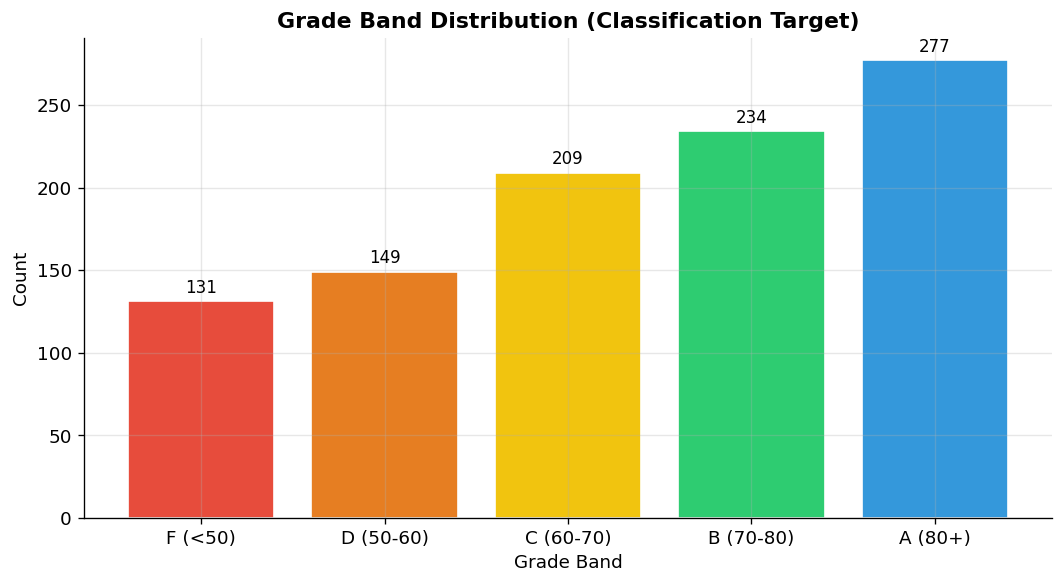

In [20]:
# ── 3.4  Power-transform skewed numerics ─────────────────────────────────────
pt = PowerTransformer(method="yeo-johnson")
skew_cols = ["screen_time", "pressure_index", "study_screen_ratio"]
df_fe[[f"{c}_pt" for c in skew_cols]] = pt.fit_transform(df_fe[skew_cols])

# ── 3.5  Polynomial features (study_hours × mental_health) ───────────────────
df_fe["study_x_mh"] = df_fe["study_hours_per_day"] * df_fe["mental_health_rating"]
df_fe["study_sq"]   = df_fe["study_hours_per_day"] ** 2
df_fe["sleep_sq"]   = df_fe["sleep_hours"] ** 2

# ── 3.6  Classification target — grade bands ─────────────────────────────────
bins   = [0, 50, 60, 70, 80, 101]
labels = ["F (<50)", "D (50-60)", "C (60-70)", "B (70-80)", "A (80+)"]
df_fe["grade_band"] = pd.cut(df_fe["exam_score"], bins=bins, labels=labels, right=False)
df_fe["grade_enc"]  = LabelEncoder().fit_transform(df_fe["grade_band"].astype(str))

print("Grade band distribution:")
print(df_fe["grade_band"].value_counts().sort_index())

# Visualise grade bands
fig, ax = plt.subplots(figsize=(9, 5))
vc = df_fe["grade_band"].value_counts().sort_index()
colors = ["#E74C3C","#E67E22","#F1C40F","#2ECC71","#3498DB"]
bars = ax.bar(vc.index.astype(str), vc.values, color=colors, edgecolor="white")
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(v), ha="center", va="bottom", fontsize=10)
ax.set_title("Grade Band Distribution (Classification Target)", fontweight="bold")
ax.set_xlabel("Grade Band"); ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(OUT_DIR / "09_grade_band_distribution.png", bbox_inches="tight", dpi=150)
plt.show()


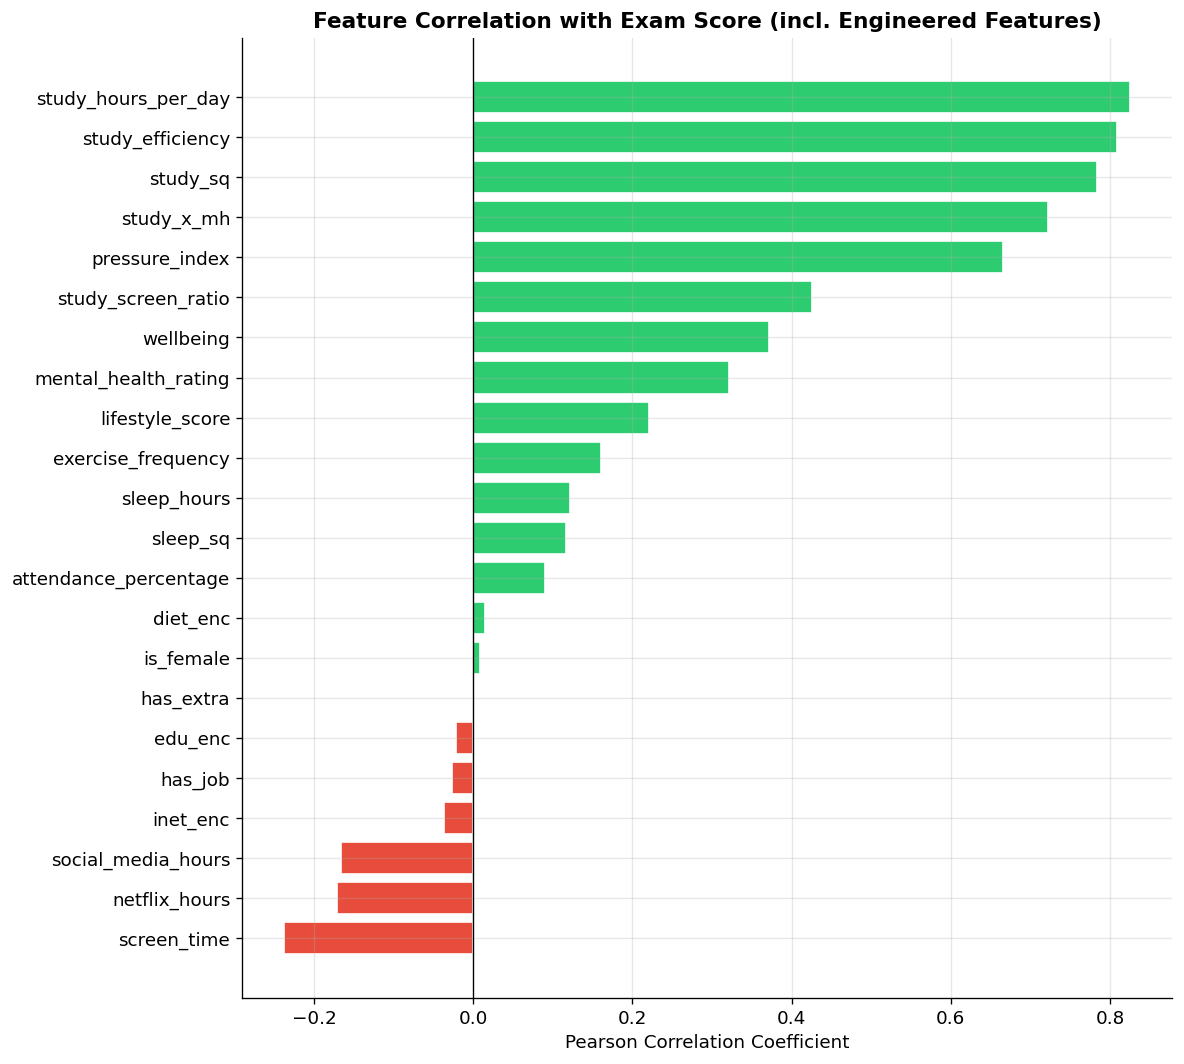

In [21]:
# ── 3.7  Feature correlation bar chart with new engineered features ────────────
eng_features = [
    "study_hours_per_day","attendance_percentage","social_media_hours",
    "netflix_hours","sleep_hours","mental_health_rating","exercise_frequency",
    "screen_time","study_efficiency","lifestyle_score","pressure_index",
    "study_screen_ratio","wellbeing","study_x_mh","study_sq","sleep_sq",
    "diet_enc","edu_enc","inet_enc","has_job","has_extra","is_female"
]
eng_features = [f for f in eng_features if f in df_fe.columns]

corr_target = df_fe[eng_features + ["exam_score"]].corr()["exam_score"].drop("exam_score").sort_values()

fig, ax = plt.subplots(figsize=(10, 9))
colors_bar = ["#E74C3C" if v < 0 else "#2ECC71" for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors_bar, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with Exam Score (incl. Engineered Features)",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Pearson Correlation Coefficient")
plt.tight_layout()
plt.savefig(OUT_DIR / "10_feature_correlation_bar.png", bbox_inches="tight", dpi=150)
plt.show()


---
## Phase 4 · Preprocessing & Train/Test Split

In [22]:
# ── 4.1  Final feature matrix ─────────────────────────────────────────────────
FEATURES = [
    "study_hours_per_day","attendance_percentage","social_media_hours",
    "netflix_hours","sleep_hours","mental_health_rating","exercise_frequency",
    "screen_time","study_efficiency","lifestyle_score","pressure_index",
    "study_screen_ratio","wellbeing","study_x_mh","study_sq","sleep_sq",
    "diet_enc","edu_enc","inet_enc","has_job","has_extra","is_female","age"
]
FEATURES = [f for f in FEATURES if f in df_fe.columns]

X = df_fe[FEATURES].copy()
y_reg  = df_fe["exam_score"].copy()          # regression target
y_clf  = df_fe["grade_enc"].copy()           # classification target

# ── 4.2  Train/test split ─────────────────────────────────────────────────────
X_train, X_test, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=SEED)

_, _, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf)

# ── 4.3  Scaling ──────────────────────────────────────────────────────────────
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"y_reg  — train mean: {y_train_r.mean():.2f}  test mean: {y_test_r.mean():.2f}")
print(f"y_clf  — classes  : {sorted(y_clf.unique())}")


Train : (800, 23)  |  Test : (200, 23)
y_reg  — train mean: 69.83  test mean: 68.70
y_clf  — classes  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


---
## Phase 5 · Regression Model Framework

In [23]:
# ── 5.1  Baseline regression models (original + extended) ─────────────────────
from scipy.stats import randint, uniform

REG_MODELS = {
    "Linear Regression"  : LinearRegression(),
    "Ridge"              : Ridge(alpha=1.0),
    "Lasso"              : Lasso(alpha=0.1),
    "ElasticNet"         : ElasticNet(alpha=0.1, l1_ratio=0.5),
    "Huber"              : HuberRegressor(epsilon=1.35),
    "Bayesian Ridge"     : BayesianRidge(),
    "KNN Regressor"      : KNeighborsRegressor(n_neighbors=7),
    "Decision Tree"      : DecisionTreeRegressor(max_depth=6, random_state=SEED),
    "Random Forest"      : RandomForestRegressor(n_estimators=200, max_depth=8,
                                                  random_state=SEED, n_jobs=-1),
    "Extra Trees"        : ExtraTreesRegressor(n_estimators=200, random_state=SEED, n_jobs=-1),
    "Gradient Boosting"  : GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                                       learning_rate=0.05, random_state=SEED),
    "AdaBoost"           : AdaBoostRegressor(n_estimators=100, random_state=SEED),
    "SVR"                : SVR(C=10, gamma="scale", epsilon=0.1),
    "XGBoost"            : xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                                              max_depth=5, subsample=0.8,
                                              colsample_bytree=0.8, random_state=SEED,
                                              verbosity=0),
    "LightGBM"           : lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05,
                                               max_depth=5, random_state=SEED,
                                               verbose=-1),
    "CatBoost"           : CatBoostRegressor(iterations=200, learning_rate=0.05,
                                              depth=5, random_seed=SEED,
                                              silent=True),
}

reg_results = {}
for name, model in REG_MODELS.items():
    t0 = time.time()
    model.fit(X_train_sc, y_train_r)
    preds = model.predict(X_test_sc)
    rmse  = np.sqrt(mean_squared_error(y_test_r, preds))
    mae   = mean_absolute_error(y_test_r, preds)
    r2    = r2_score(y_test_r, preds)
    elapsed = time.time() - t0
    reg_results[name] = {"RMSE": rmse, "MAE": mae, "R²": r2, "Time(s)": elapsed}
    print(f"{name:<25}  R²={r2:.4f}  RMSE={rmse:.3f}  MAE={mae:.3f}  ({elapsed:.1f}s)")

reg_df = pd.DataFrame(reg_results).T.sort_values("R²", ascending=False)
print("\n── Top-5 regressors ──")
print(reg_df.head(5).round(4))


Linear Regression          R²=0.9024  RMSE=5.004  MAE=4.068  (0.1s)
Ridge                      R²=0.9018  RMSE=5.018  MAE=4.090  (0.0s)
Lasso                      R²=0.8995  RMSE=5.077  MAE=4.131  (0.0s)
ElasticNet                 R²=0.8920  RMSE=5.261  MAE=4.296  (0.0s)
Huber                      R²=0.9007  RMSE=5.047  MAE=4.124  (0.3s)
Bayesian Ridge             R²=0.9014  RMSE=5.027  MAE=4.102  (0.0s)
KNN Regressor              R²=0.8021  RMSE=7.124  MAE=5.667  (0.1s)
Decision Tree              R²=0.7804  RMSE=7.503  MAE=5.881  (0.0s)
Random Forest              R²=0.8768  RMSE=5.620  MAE=4.476  (2.9s)
Extra Trees                R²=0.8789  RMSE=5.573  MAE=4.501  (2.2s)
Gradient Boosting          R²=0.8738  RMSE=5.689  MAE=4.515  (2.6s)
AdaBoost                   R²=0.8479  RMSE=6.246  MAE=5.071  (2.0s)
SVR                        R²=0.8656  RMSE=5.872  MAE=4.844  (0.3s)
XGBoost                    R²=0.8814  RMSE=5.516  MAE=4.452  (2.6s)
LightGBM                   R²=0.8670  RMSE=5.839

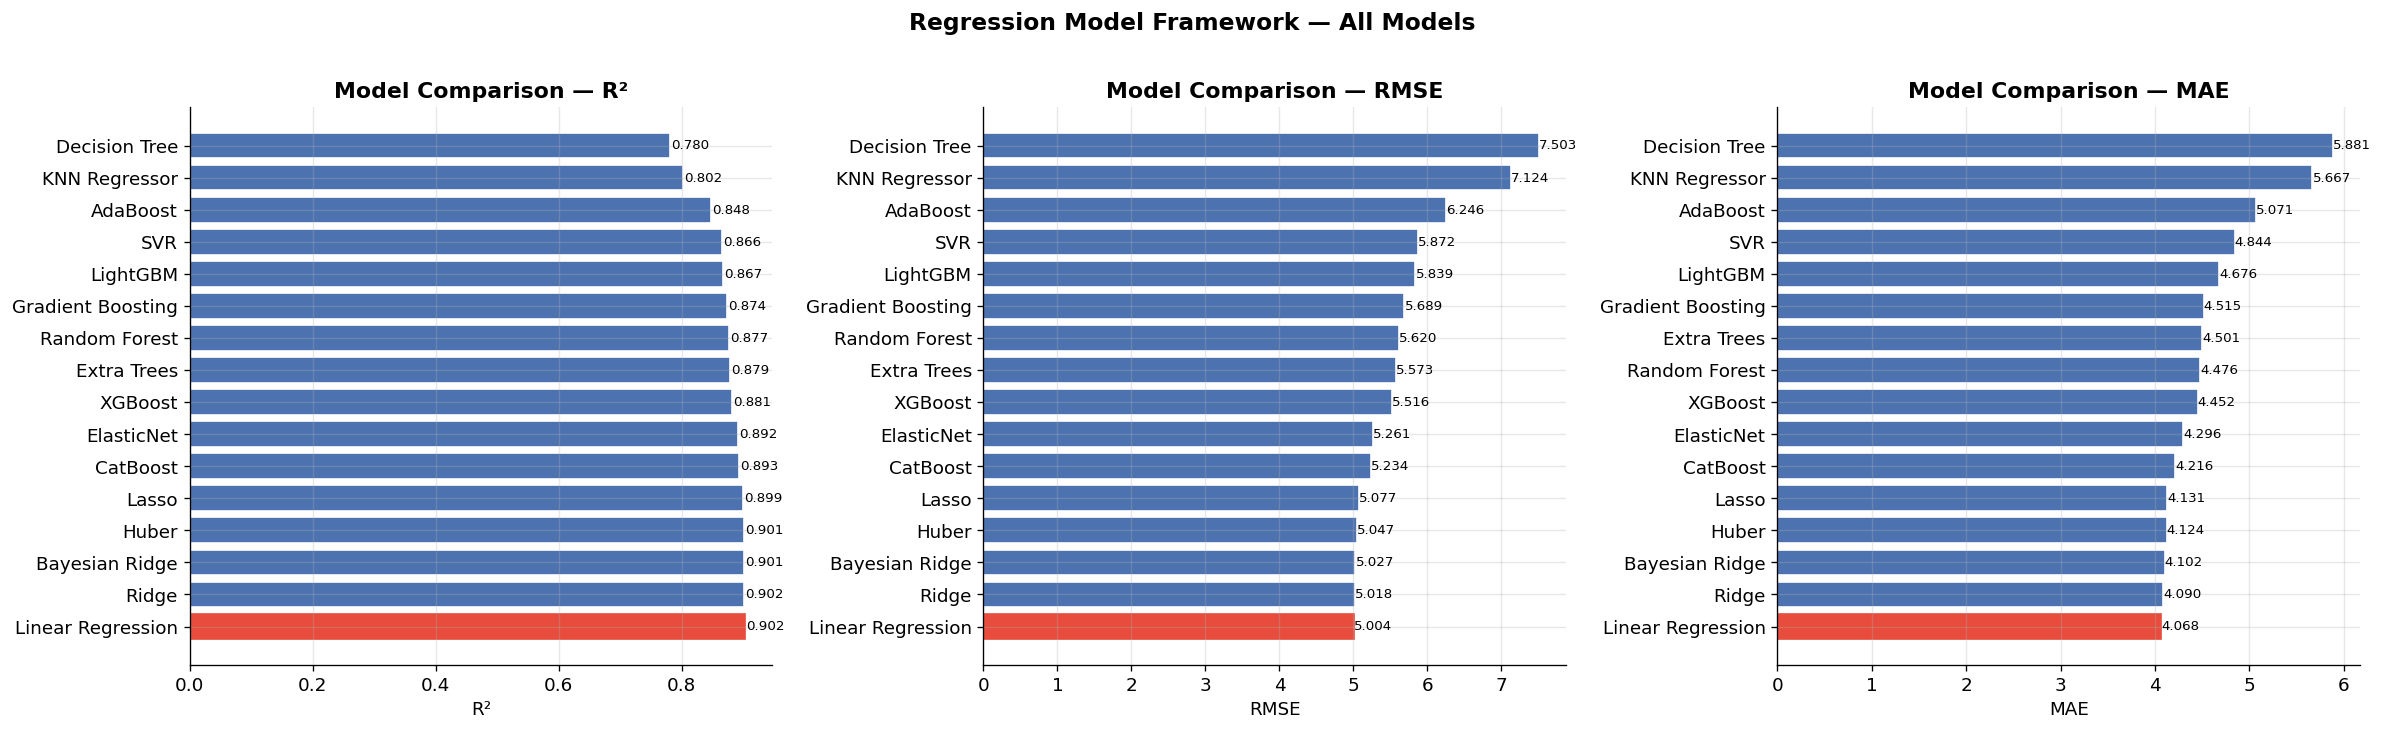

In [24]:
# ── 5.2  Regression results visualisation ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metrics_to_plot = ["R²", "RMSE", "MAE"]
for ax, metric in zip(axes, metrics_to_plot):
    data_sorted = reg_df[metric].sort_values(ascending=(metric != "R²"))
    colors_bar  = ["#2ECC71" if i == 0 else "#3498DB" for i in range(len(data_sorted))]
    bars = ax.barh(data_sorted.index, data_sorted.values,
                   color="#4C72B0", edgecolor="white")
    best_idx = data_sorted.index[0]
    bars[0].set_color("#E74C3C")
    ax.set_title(f"Model Comparison — {metric}", fontweight="bold")
    ax.set_xlabel(metric)
    for bar, val in zip(bars, data_sorted.values):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=8)

plt.suptitle("Regression Model Framework — All Models", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "11_regression_model_comparison.png", bbox_inches="tight", dpi=150)
plt.show()


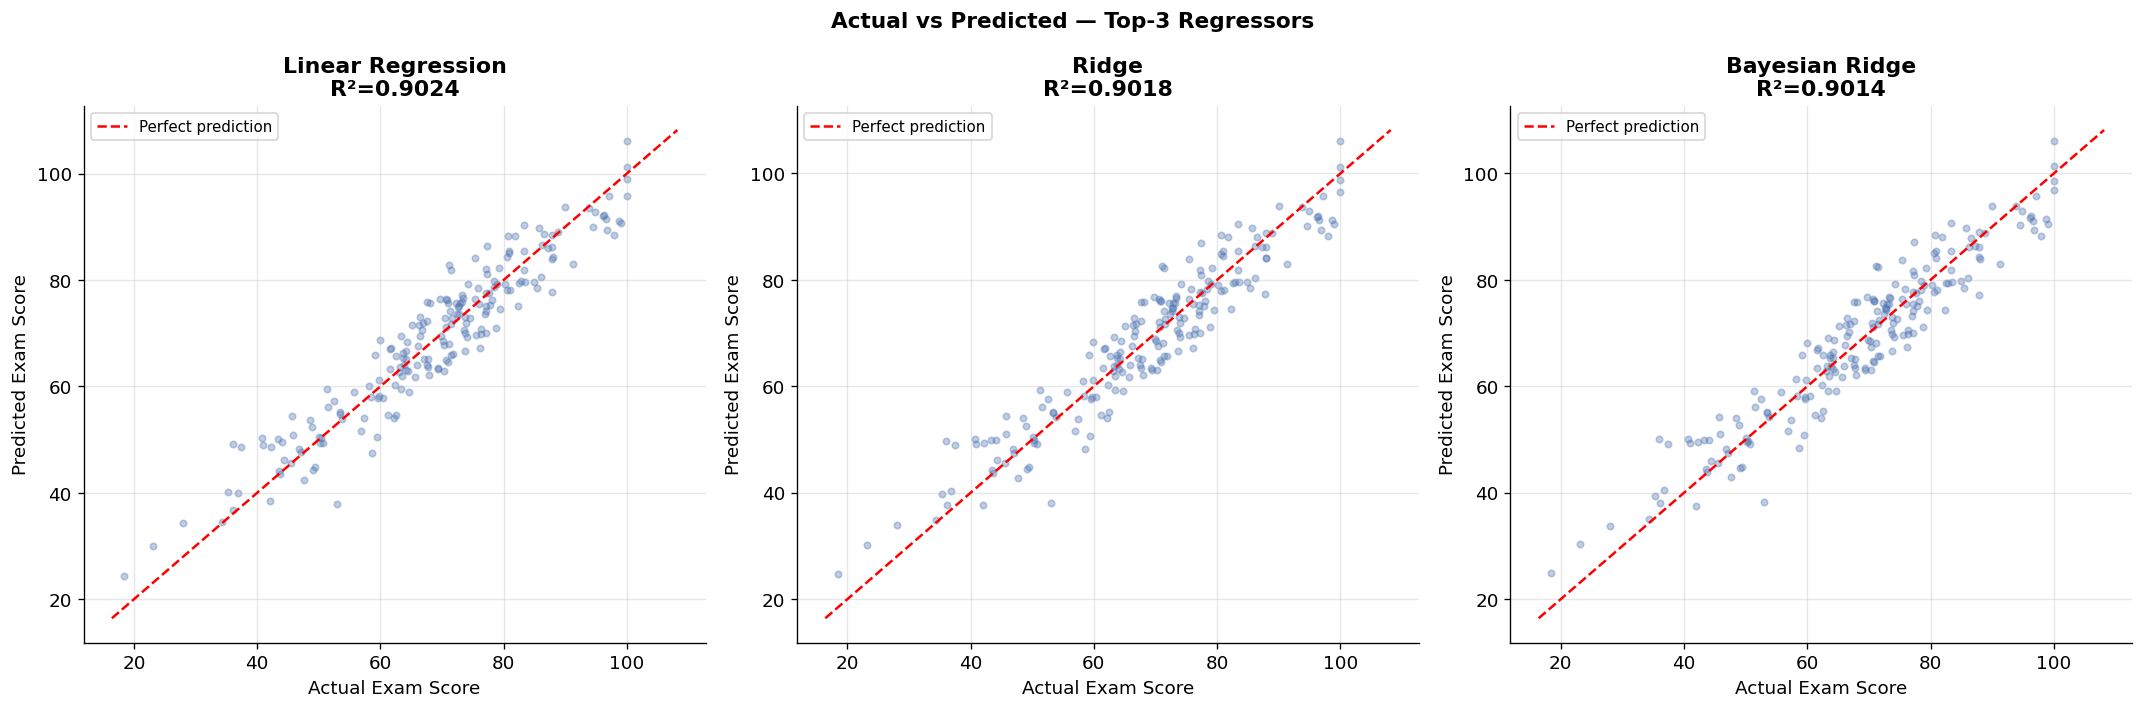

In [25]:
# ── 5.3  Actual vs Predicted — top-3 models ──────────────────────────────────
top3_reg = reg_df.head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, name in zip(axes, top3_reg):
    model  = REG_MODELS[name]
    preds  = model.predict(X_test_sc)
    ax.scatter(y_test_r, preds, alpha=0.35, s=15, color="#4C72B0")
    lims   = [min(y_test_r.min(), preds.min())-2, max(y_test_r.max(), preds.max())+2]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
    ax.set_title(f"{name}\nR²={r2_score(y_test_r, preds):.4f}", fontweight="bold")
    ax.set_xlabel("Actual Exam Score")
    ax.set_ylabel("Predicted Exam Score")
    ax.legend(fontsize=9)

plt.suptitle("Actual vs Predicted — Top-3 Regressors", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "12_actual_vs_predicted_top3.png", bbox_inches="tight", dpi=150)
plt.show()


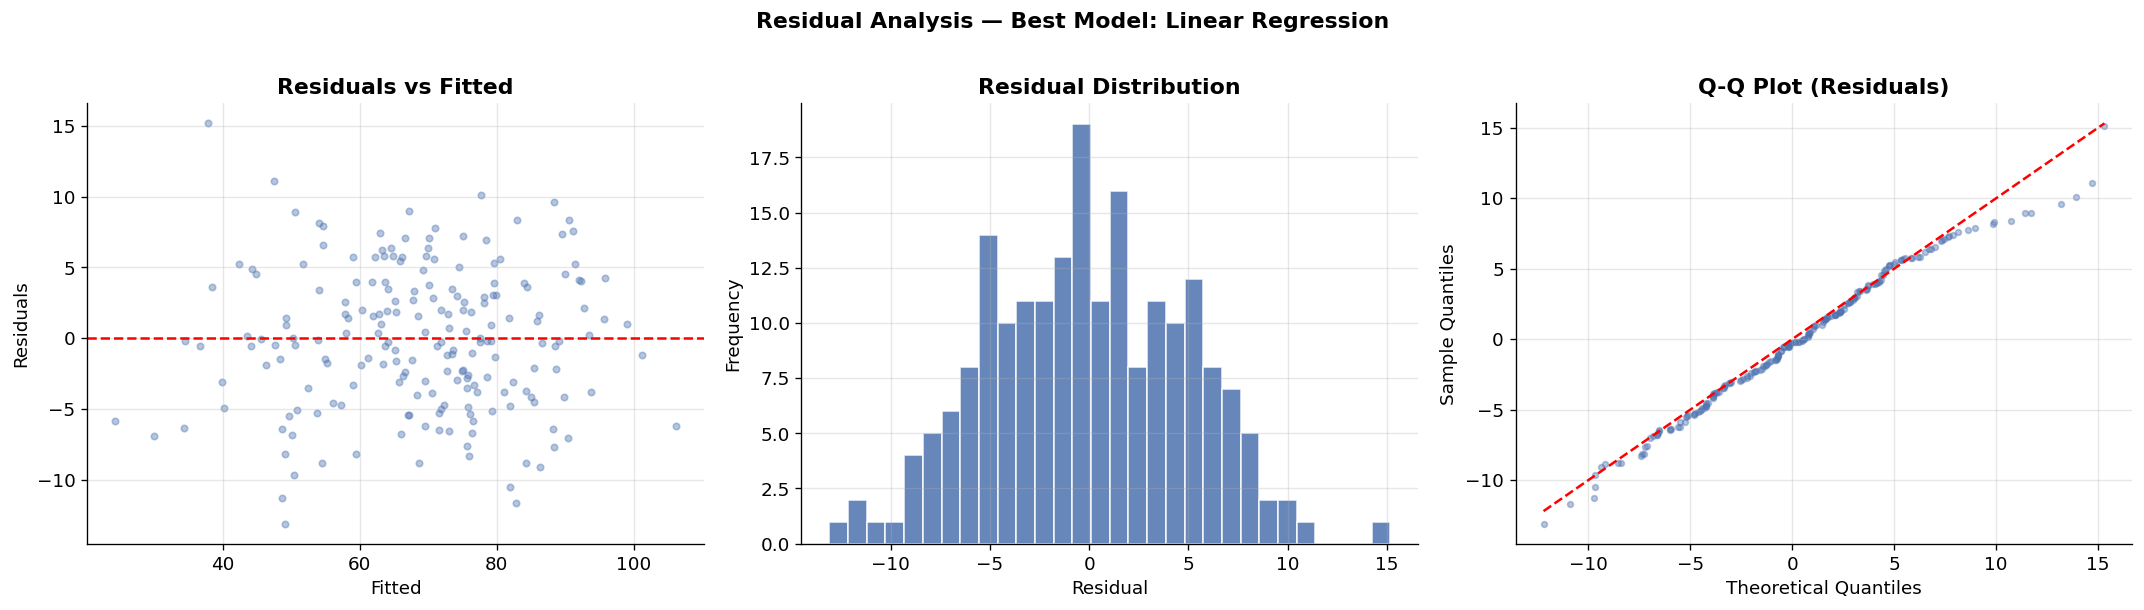

In [26]:
# ── 5.4  Residual analysis ────────────────────────────────────────────────────
best_reg_name = reg_df.index[0]
best_reg_model = REG_MODELS[best_reg_name]
best_preds_r = best_reg_model.predict(X_test_sc)
residuals = y_test_r.values - best_preds_r

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuals vs fitted
axes[0].scatter(best_preds_r, residuals, alpha=0.4, s=15, color="#4C72B0")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuals vs Fitted", fontweight="bold")
axes[0].set_xlabel("Fitted"); axes[0].set_ylabel("Residuals")

# Histogram of residuals
axes[1].hist(residuals, bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[1].set_title("Residual Distribution", fontweight="bold")
axes[1].set_xlabel("Residual"); axes[1].set_ylabel("Frequency")

# QQ-like: sorted residuals
sorted_res = np.sort(residuals)
n = len(sorted_res)
theoretical = np.sort(np.random.normal(0, residuals.std(), n))
axes[2].scatter(theoretical, sorted_res, alpha=0.4, s=12, color="#4C72B0")
axes[2].plot([theoretical.min(), theoretical.max()],
             [theoretical.min(), theoretical.max()], "r--", linewidth=1.5)
axes[2].set_title("Q-Q Plot (Residuals)", fontweight="bold")
axes[2].set_xlabel("Theoretical Quantiles"); axes[2].set_ylabel("Sample Quantiles")

plt.suptitle(f"Residual Analysis — Best Model: {best_reg_name}", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "13_residual_analysis.png", bbox_inches="tight", dpi=150)
plt.show()
# ▶ Interpretation: random scatter around 0 confirms no systematic bias.
#   Normal Q-Q alignment validates that residuals are approximately Gaussian.


---
## Phase 6 · Classification Model Framework (Grade Band Prediction)

In [27]:
# ── 6.1  All classification models ───────────────────────────────────────────
CLF_MODELS = {
    "Logistic Regression"      : LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
    "Logistic (L1)"            : LogisticRegression(penalty="l1", solver="saga",
                                                     max_iter=1000, C=1.0, random_state=SEED),
    "Logistic (ElasticNet)"    : LogisticRegression(penalty="elasticnet", solver="saga",
                                                     l1_ratio=0.5, max_iter=1000,
                                                     random_state=SEED),
    "LDA"                      : LinearDiscriminantAnalysis(),
    "QDA"                      : QuadraticDiscriminantAnalysis(),
    "Naive Bayes"              : GaussianNB(),
    "KNN"                      : KNeighborsClassifier(n_neighbors=7),
    "Decision Tree"            : DecisionTreeClassifier(max_depth=6, random_state=SEED),
    "Random Forest"            : RandomForestClassifier(n_estimators=200, max_depth=8,
                                                         random_state=SEED, n_jobs=-1),
    "Extra Trees"              : ExtraTreesClassifier(n_estimators=200, random_state=SEED,
                                                       n_jobs=-1),
    "Gradient Boosting"        : GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                              learning_rate=0.05,
                                                              random_state=SEED),
    "AdaBoost"                 : AdaBoostClassifier(n_estimators=100, random_state=SEED),
    "SVC (RBF)"                : SVC(C=10, gamma="scale", probability=True,
                                      random_state=SEED),
    "SVC (Linear)"             : SVC(kernel="linear", C=1.0, probability=True,
                                      random_state=SEED),
    "SGD Classifier"           : SGDClassifier(loss="modified_huber", max_iter=1000,
                                                random_state=SEED),
    "XGBoost"                  : xgb.XGBClassifier(n_estimators=200, learning_rate=0.05,
                                                     max_depth=5, subsample=0.8,
                                                     use_label_encoder=False,
                                                     eval_metric="mlogloss",
                                                     random_state=SEED, verbosity=0),
    "LightGBM"                 : lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05,
                                                      max_depth=5, random_state=SEED,
                                                      verbose=-1),
    "CatBoost"                 : CatBoostClassifier(iterations=200, learning_rate=0.05,
                                                     depth=5, random_seed=SEED,
                                                     silent=True),
}

clf_results = {}
for name, model in CLF_MODELS.items():
    t0 = time.time()
    model.fit(X_train_sc, y_train_c)
    preds  = model.predict(X_test_sc)
    acc    = accuracy_score(y_test_c, preds)
    f1     = f1_score(y_test_c, preds, average="weighted")
    elapsed = time.time() - t0
    clf_results[name] = {"Accuracy": acc, "F1 (weighted)": f1, "Time(s)": elapsed}
    print(f"{name:<30}  Acc={acc:.4f}  F1={f1:.4f}  ({elapsed:.1f}s)")

clf_df = pd.DataFrame(clf_results).T.sort_values("Accuracy", ascending=False)
print("\n── Top-5 classifiers ──")
print(clf_df.head(5).round(4))


Logistic Regression             Acc=0.2450  F1=0.2039  (0.2s)
Logistic (L1)                   Acc=0.2600  F1=0.2200  (2.9s)
Logistic (ElasticNet)           Acc=0.2500  F1=0.2076  (2.4s)
LDA                             Acc=0.2350  F1=0.1945  (0.0s)
QDA                             Acc=0.1900  F1=0.1664  (0.0s)
Naive Bayes                     Acc=0.2750  F1=0.2369  (0.0s)
KNN                             Acc=0.2700  F1=0.2427  (0.0s)
Decision Tree                   Acc=0.2400  F1=0.1994  (0.0s)
Random Forest                   Acc=0.2800  F1=0.2078  (1.5s)
Extra Trees                     Acc=0.2750  F1=0.2349  (1.3s)
Gradient Boosting               Acc=0.2400  F1=0.2231  (14.3s)
AdaBoost                        Acc=0.2850  F1=0.2611  (1.0s)
SVC (RBF)                       Acc=0.2850  F1=0.2720  (2.1s)
SVC (Linear)                    Acc=0.2700  F1=0.1842  (2.0s)
SGD Classifier                  Acc=0.2400  F1=0.2372  (0.1s)
XGBoost                         Acc=0.2500  F1=0.2292  (3.6s)
LightGB

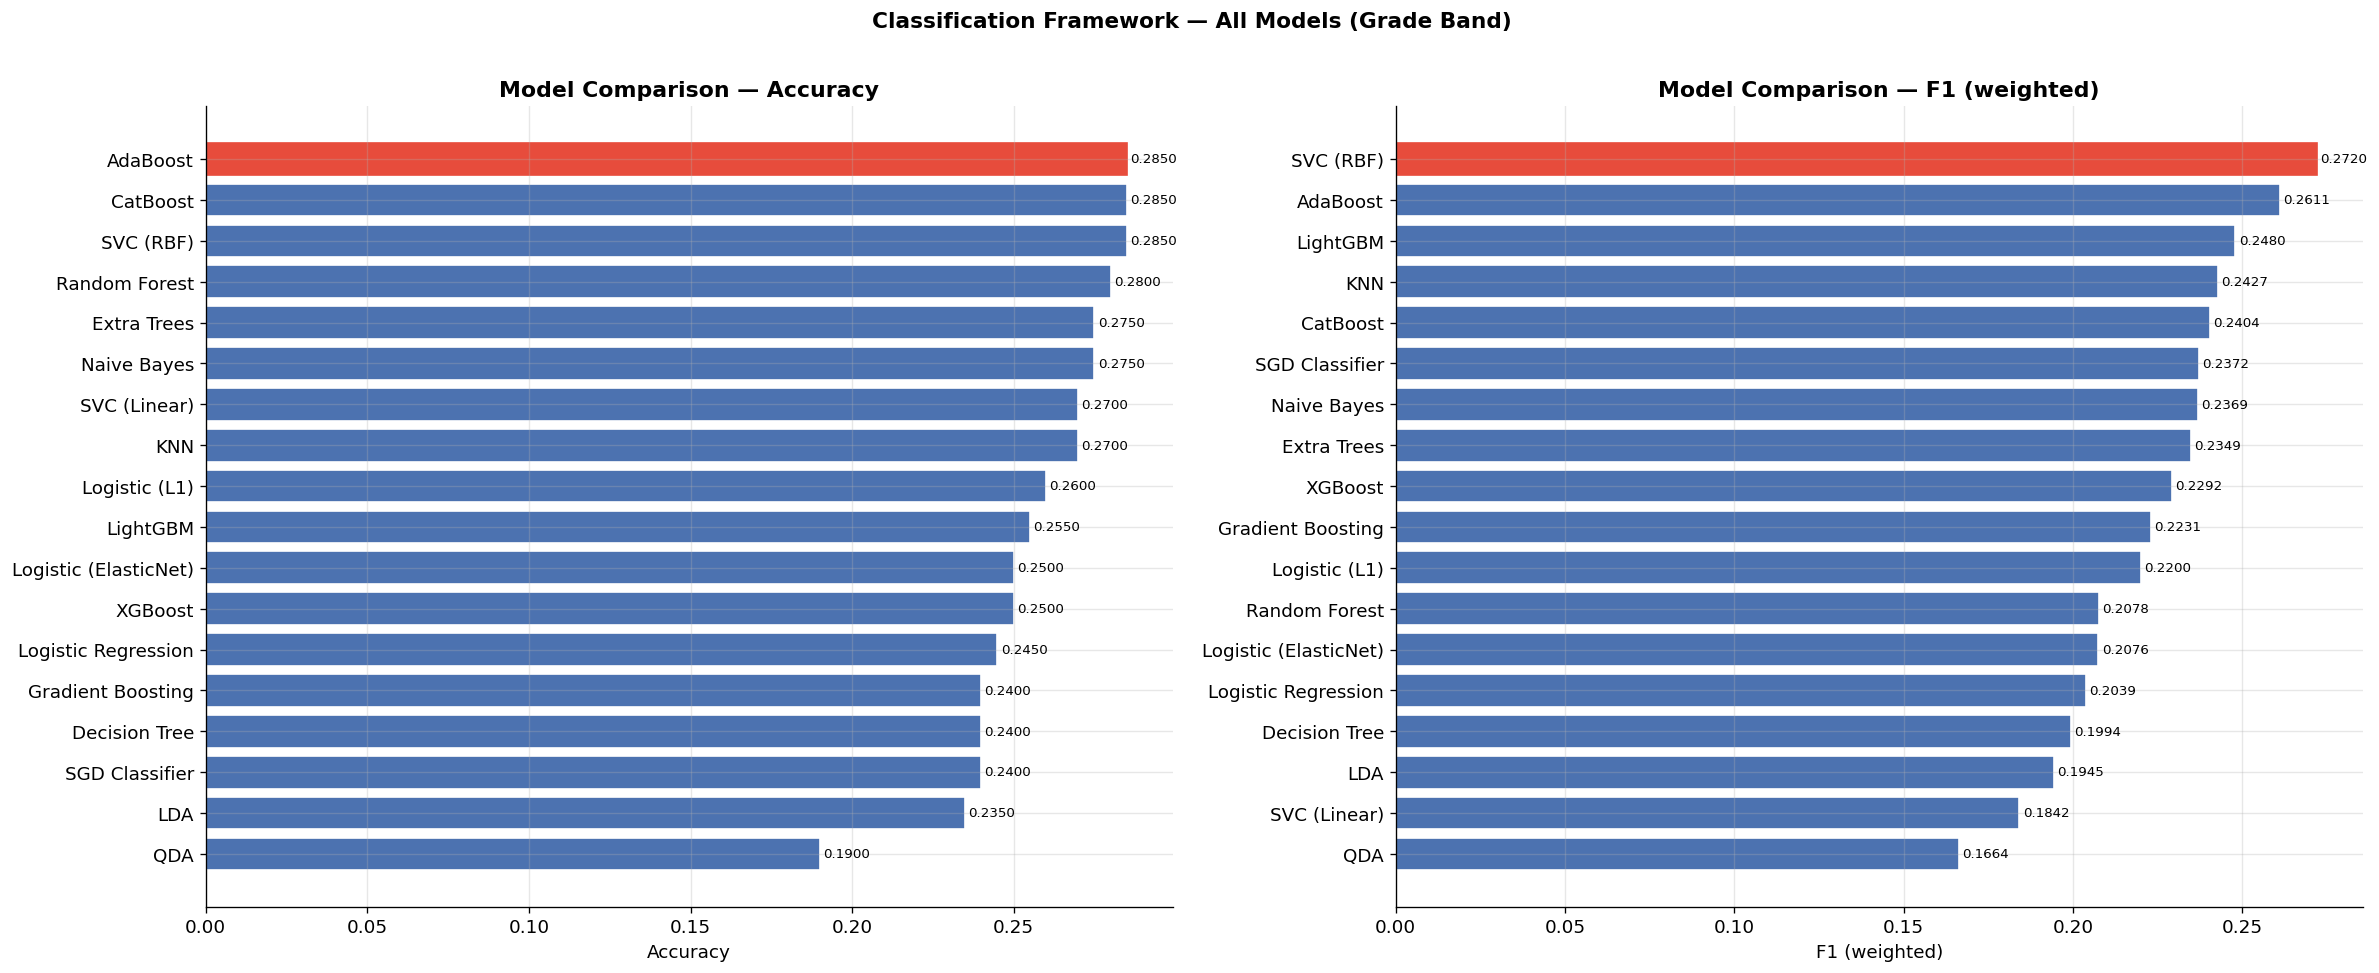

In [28]:
# ── 6.2  Classification comparison chart ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, metric in zip(axes, ["Accuracy", "F1 (weighted)"]):
    data_sorted = clf_df[metric].sort_values()
    colors_list = ["#E74C3C" if i == len(data_sorted)-1 else "#4C72B0"
                   for i in range(len(data_sorted))]
    bars = ax.barh(data_sorted.index, data_sorted.values,
                   color="#4C72B0", edgecolor="white")
    bars[-1].set_color("#E74C3C")
    ax.set_title(f"Model Comparison — {metric}", fontweight="bold")
    ax.set_xlabel(metric)
    for bar, val in zip(bars, data_sorted.values):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=8)

plt.suptitle("Classification Framework — All Models (Grade Band)", fontsize=13,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "14_classification_comparison.png", bbox_inches="tight", dpi=150)
plt.show()


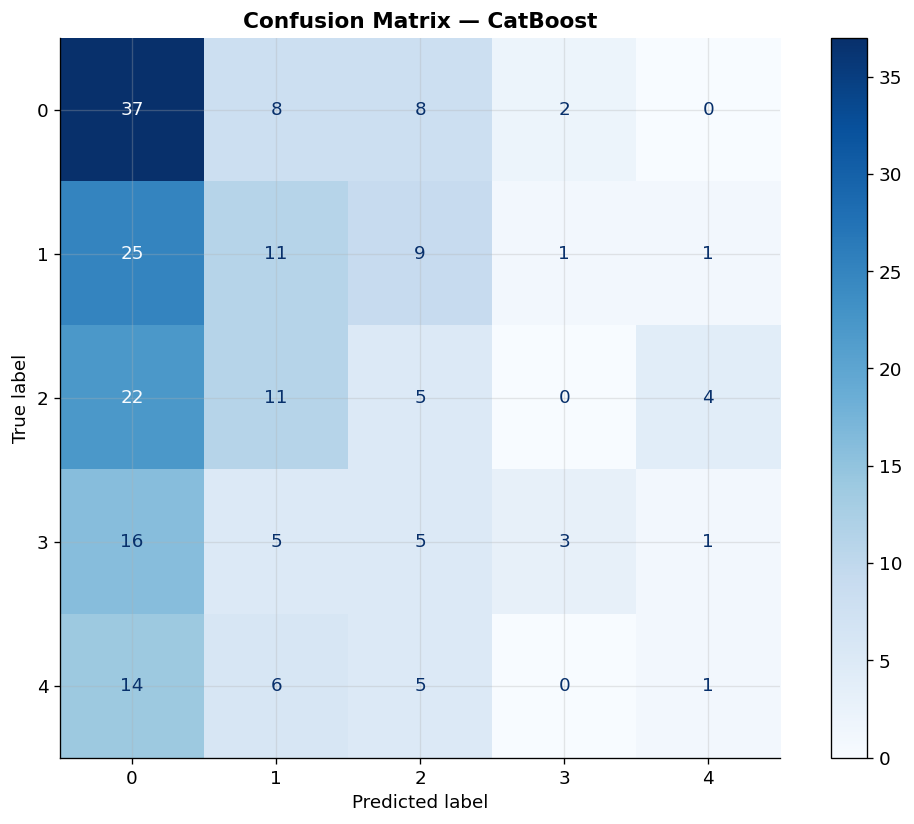

Classification Report — CatBoost
              precision    recall  f1-score   support

           0       0.32      0.67      0.44        55
           1       0.27      0.23      0.25        47
           2       0.16      0.12      0.14        42
           3       0.50      0.10      0.17        30
           4       0.14      0.04      0.06        26

    accuracy                           0.28       200
   macro avg       0.28      0.23      0.21       200
weighted avg       0.28      0.28      0.24       200



In [29]:
# ── 6.3  Confusion matrix — best classifier ───────────────────────────────────
best_clf_name  = clf_df.index[0]
best_clf_model = CLF_MODELS[best_clf_name]
best_preds_c   = best_clf_model.predict(X_test_sc)

grade_labels_str = [str(l) for l in sorted(df_fe["grade_band"].unique())]

fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_test_c, best_preds_c)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title(f"Confusion Matrix — {best_clf_name}", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "15_confusion_matrix.png", bbox_inches="tight", dpi=150)
plt.show()

# Classification report
print(f"Classification Report — {best_clf_name}")
print(classification_report(y_test_c, best_preds_c))


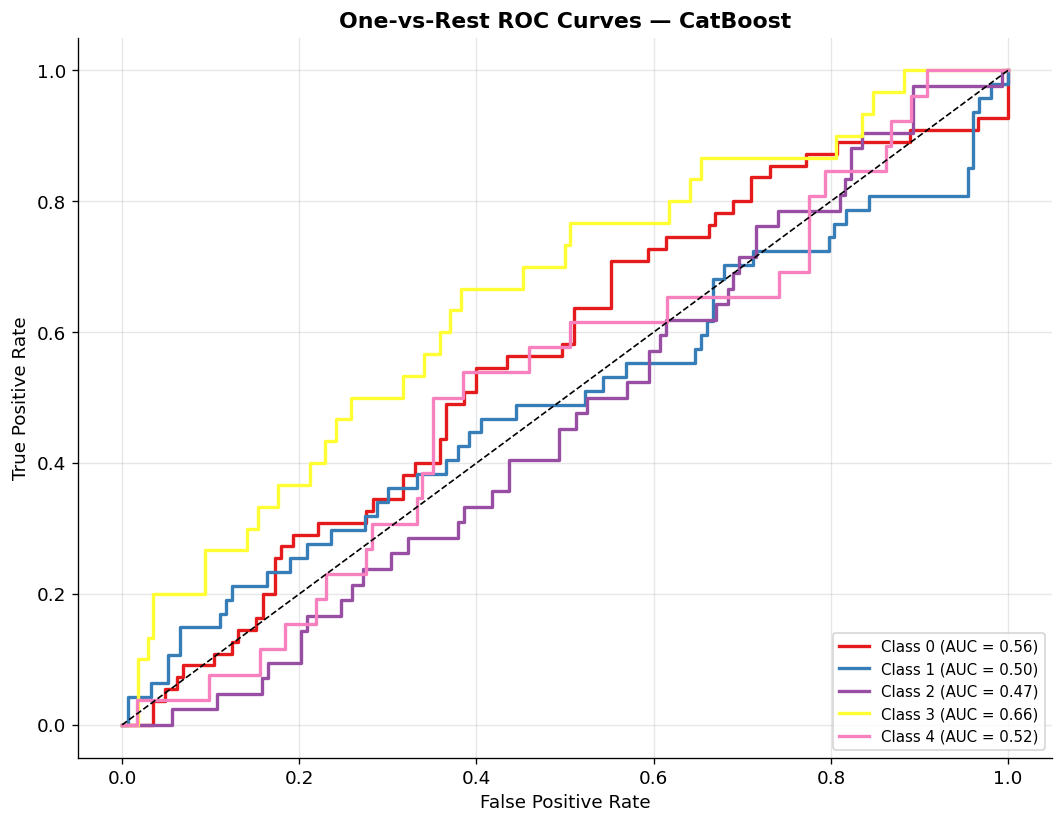

In [30]:
# ── 6.4  Macro ROC curves — best classifier ───────────────────────────────────
from sklearn.preprocessing import label_binarize

n_classes = len(df_fe["grade_enc"].unique())
y_test_bin = label_binarize(y_test_c, classes=list(range(n_classes)))

if hasattr(best_clf_model, "predict_proba"):
    y_score = best_clf_model.predict_proba(X_test_sc)
    fig, ax = plt.subplots(figsize=(9, 7))
    colors_roc = plt.cm.Set1(np.linspace(0, 0.8, n_classes))
    for i, color in zip(range(n_classes), colors_roc):
        if y_test_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f"Class {i} (AUC = {roc_auc_val:.2f})")
    ax.plot([0,1],[0,1],"k--", linewidth=1)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(f"One-vs-Rest ROC Curves — {best_clf_name}", fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "16_roc_curves.png", bbox_inches="tight", dpi=150)
    plt.show()


---
## Phase 7 · Ultra-Advanced Hyperparameter Tuning (Optuna + RandomizedSearchCV)

In [31]:
# ── 7.1  Optuna — XGBoost Regressor ──────────────────────────────────────────
def objective_xgb_reg(trial):
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 100, 600),
        max_depth        = trial.suggest_int("max_depth", 3, 10),
        learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample        = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha        = trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        min_child_weight = trial.suggest_int("min_child_weight", 1, 10),
        gamma            = trial.suggest_float("gamma", 0, 5),
    )
    model = xgb.XGBRegressor(**params, random_state=SEED, verbosity=0)
    # 5-fold CV
    cv_scores = cross_val_score(model, X_train_sc, y_train_r,
                                 cv=5, scoring="r2", n_jobs=-1)
    return cv_scores.mean()

study_xgb = optuna.create_study(direction="maximize",
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(objective_xgb_reg, n_trials=60, show_progress_bar=False)

print(f"Best XGBoost R² (CV): {study_xgb.best_value:.4f}")
print(f"Best params: {study_xgb.best_params}")


Best XGBoost R² (CV): 0.8887
Best params: {'n_estimators': 444, 'max_depth': 5, 'learning_rate': 0.0174343284636044, 'subsample': 0.5306347557571582, 'colsample_bytree': 0.6237734011027739, 'reg_alpha': 0.02185965428542038, 'reg_lambda': 0.7139526911993068, 'min_child_weight': 10, 'gamma': 2.451688627603418}


Tuned XGBoost  →  R²=0.8914  RMSE=5.277


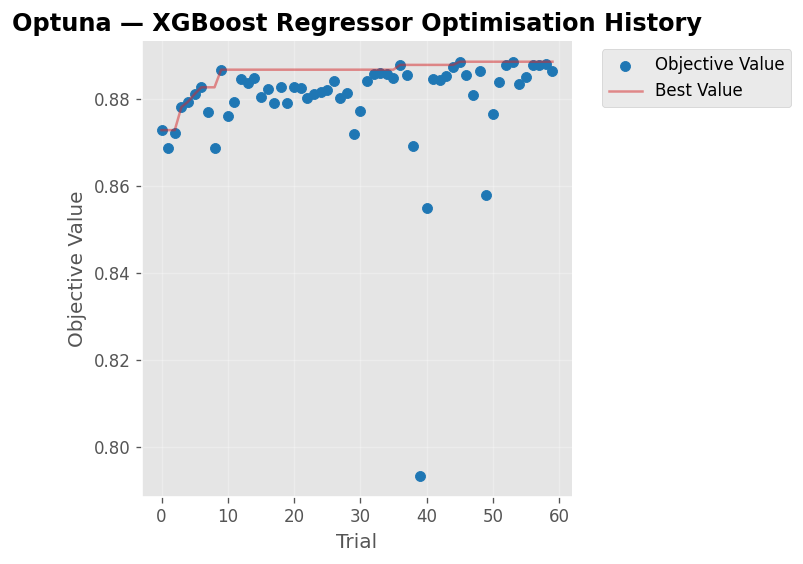

In [32]:
# ── 7.2  Refit best XGBoost regressor ────────────────────────────────────────
best_xgb_reg = xgb.XGBRegressor(**study_xgb.best_params, random_state=SEED, verbosity=0)
best_xgb_reg.fit(X_train_sc, y_train_r)
xgb_preds = best_xgb_reg.predict(X_test_sc)

xgb_r2   = r2_score(y_test_r, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test_r, xgb_preds))
print(f"Tuned XGBoost  →  R²={xgb_r2:.4f}  RMSE={xgb_rmse:.3f}")

# Optuna optimisation history
fig = optuna.visualization.matplotlib.plot_optimization_history(study_xgb)
plt.title("Optuna — XGBoost Regressor Optimisation History", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "17_optuna_xgb_history.png", bbox_inches="tight", dpi=150)
plt.show()


In [33]:
# ── 7.3  Optuna — LightGBM Classifier ────────────────────────────────────────
def objective_lgb_clf(trial):
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 100, 600),
        max_depth        = trial.suggest_int("max_depth", 3, 10),
        learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample        = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha        = trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        num_leaves       = trial.suggest_int("num_leaves", 20, 150),
        min_child_samples= trial.suggest_int("min_child_samples", 5, 50),
    )
    model = lgb.LGBMClassifier(**params, random_state=SEED, verbose=-1)
    cv_scores = cross_val_score(model, X_train_sc, y_train_c,
                                 cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                                 scoring="f1_weighted", n_jobs=-1)
    return cv_scores.mean()

study_lgb = optuna.create_study(direction="maximize",
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(objective_lgb_clf, n_trials=60, show_progress_bar=False)

print(f"Best LightGBM F1 (CV): {study_lgb.best_value:.4f}")
print(f"Best params: {study_lgb.best_params}")


Best LightGBM F1 (CV): 0.2313
Best params: {'n_estimators': 565, 'max_depth': 5, 'learning_rate': 0.048895286512699185, 'subsample': 0.5842364537435607, 'colsample_bytree': 0.7100717108017474, 'reg_alpha': 0.03916440273276325, 'reg_lambda': 0.0023305658285817077, 'num_leaves': 92, 'min_child_samples': 47}


Tuned LightGBM  →  Accuracy=0.2400  F1=0.2335


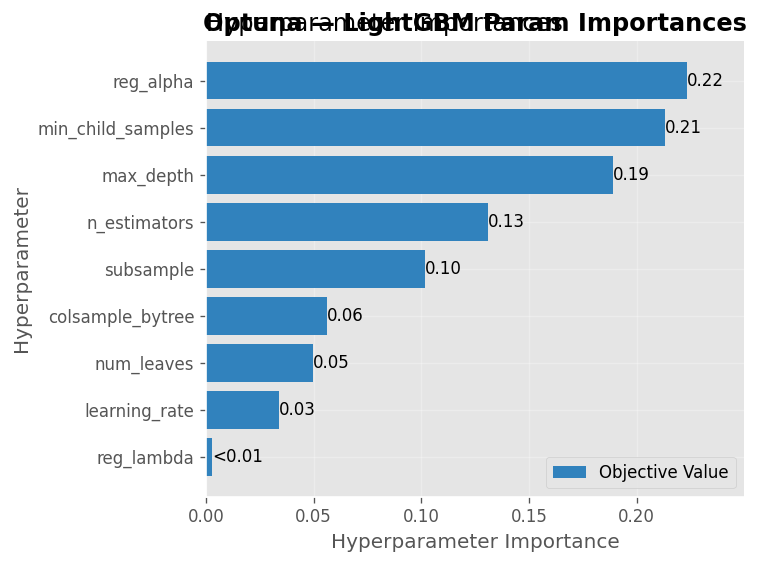

In [34]:
# ── 7.4  Refit best LightGBM classifier ──────────────────────────────────────
best_lgb_clf = lgb.LGBMClassifier(**study_lgb.best_params, random_state=SEED, verbose=-1)
best_lgb_clf.fit(X_train_sc, y_train_c)
lgb_preds = best_lgb_clf.predict(X_test_sc)

lgb_acc = accuracy_score(y_test_c, lgb_preds)
lgb_f1  = f1_score(y_test_c, lgb_preds, average="weighted")
print(f"Tuned LightGBM  →  Accuracy={lgb_acc:.4f}  F1={lgb_f1:.4f}")

# Optuna importance
fig = optuna.visualization.matplotlib.plot_param_importances(study_lgb)
plt.title("Optuna — LightGBM Param Importances", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "18_optuna_lgb_param_importance.png", bbox_inches="tight", dpi=150)
plt.show()


In [36]:
# ── 7.5  RandomizedSearchCV — CatBoost Classifier ─────────────────────────────
from scipy.stats import randint, uniform

cat_param_dist = {
    "iterations"    : randint(50, 200),      # reduced from 100-400
    "learning_rate" : uniform(0.03, 0.17),   # 0.03 - 0.20
    "depth"         : randint(3, 7),         # reduced depth
    "l2_leaf_reg"   : uniform(1, 5),         # smaller search space
    "border_count"  : randint(32, 128),      # reduced range
}

cat_base = CatBoostClassifier(random_seed=SEED, silent=True)

cat_search = RandomizedSearchCV(
    cat_base,
    cat_param_dist,
    n_iter=10,  # reduced from 30 for faster execution
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring="f1_weighted",
    n_jobs=1,   # CatBoost manages its own threads
    random_state=SEED,
    verbose=3   # shows progress
)

cat_search.fit(X_train_sc, y_train_c)

cat_best = cat_search.best_estimator_
cat_preds = cat_best.predict(X_test_sc)

print(f"Tuned CatBoost  →  Accuracy={accuracy_score(y_test_c, cat_preds):.4f}")
print(f"Best params: {cat_search.best_params_}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END border_count=83, depth=3, iterations=64, l2_leaf_reg=4.659969709057025, learning_rate=0.13177194231349623;, score=0.167 total time=   0.3s
[CV 2/5] END border_count=83, depth=3, iterations=64, l2_leaf_reg=4.659969709057025, learning_rate=0.13177194231349623;, score=0.183 total time=   0.4s
[CV 3/5] END border_count=83, depth=3, iterations=64, l2_leaf_reg=4.659969709057025, learning_rate=0.13177194231349623;, score=0.195 total time=   0.6s
[CV 4/5] END border_count=83, depth=3, iterations=64, l2_leaf_reg=4.659969709057025, learning_rate=0.13177194231349623;, score=0.222 total time=   0.5s
[CV 5/5] END border_count=83, depth=3, iterations=64, l2_leaf_reg=4.659969709057025, learning_rate=0.13177194231349623;, score=0.245 total time=   0.4s
[CV 1/5] END border_count=114, depth=5, iterations=124, l2_leaf_reg=3.2962444598293357, learning_rate=0.08673046389363372;, score=0.156 total time=   1.9s
[CV 2/5] END border_coun

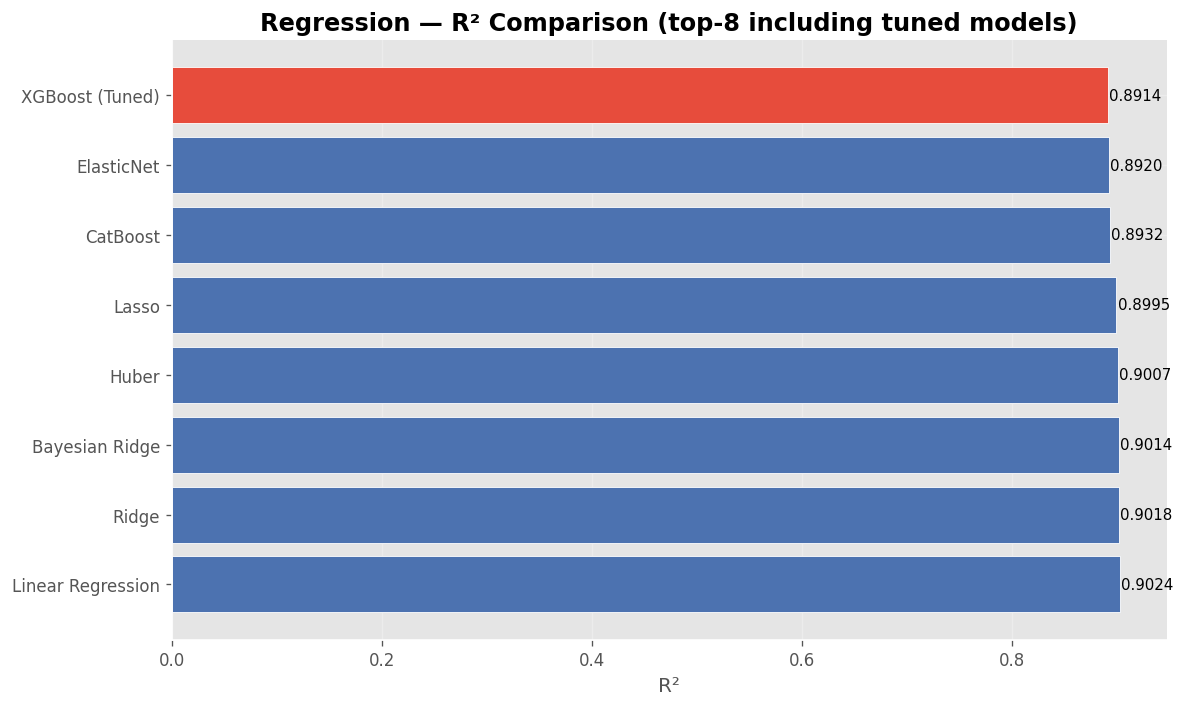

In [37]:
# ── 7.6  Tuned model comparison chart ─────────────────────────────────────────
tuned_comparison = {
    "XGBoost (Tuned)"   : {"R²": xgb_r2, "RMSE": xgb_rmse},
}

# Update reg_df with tuned XGBoost
reg_df.loc["XGBoost (Tuned)"] = {"R²": xgb_r2, "RMSE": xgb_rmse, "MAE": mean_absolute_error(y_test_r, xgb_preds), "Time(s)": 0}
reg_df_disp = reg_df.sort_values("R²", ascending=False).head(8)

fig, ax = plt.subplots(figsize=(10, 6))
colors_list = ["#E74C3C" if "Tuned" in n else "#4C72B0" for n in reg_df_disp.index]
bars = ax.barh(reg_df_disp.index, reg_df_disp["R²"], color=colors_list, edgecolor="white")
ax.set_title("Regression — R² Comparison (top-8 including tuned models)", fontweight="bold")
ax.set_xlabel("R²")
for bar, val in zip(bars, reg_df_disp["R²"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / "19_tuned_model_comparison.png", bbox_inches="tight", dpi=150)
plt.show()


---
## Phase 8 · Model Orchestration — Stacking & Voting Ensemble

In [38]:
# ── 8.1  Stacking Regressor ───────────────────────────────────────────────────
stack_estimators_reg = [
    ("ridge",   Ridge(alpha=1.0)),
    ("rf",      RandomForestRegressor(n_estimators=150, max_depth=8, random_state=SEED)),
    ("xgb",     xgb.XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=5,
                                   random_state=SEED, verbosity=0)),
    ("lgb",     lgb.LGBMRegressor(n_estimators=150, learning_rate=0.05,
                                    random_state=SEED, verbose=-1)),
]
stacking_reg = StackingRegressor(
    estimators=stack_estimators_reg,
    final_estimator=Ridge(alpha=0.5),
    cv=5, n_jobs=-1
)
stacking_reg.fit(X_train_sc, y_train_r)
stack_preds_r = stacking_reg.predict(X_test_sc)
stack_r2   = r2_score(y_test_r, stack_preds_r)
stack_rmse = np.sqrt(mean_squared_error(y_test_r, stack_preds_r))
print(f"Stacking Regressor  →  R²={stack_r2:.4f}  RMSE={stack_rmse:.3f}")


Stacking Regressor  →  R²=0.9013  RMSE=5.031


In [39]:
# ── 8.2  Stacking Classifier ──────────────────────────────────────────────────
stack_estimators_clf = [
    ("lr",  LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)),
    ("rf",  RandomForestClassifier(n_estimators=150, max_depth=8, random_state=SEED)),
    ("xgb", xgb.XGBClassifier(n_estimators=150, learning_rate=0.05, max_depth=5,
                                eval_metric="mlogloss", random_state=SEED, verbosity=0)),
    ("lgb", lgb.LGBMClassifier(n_estimators=150, learning_rate=0.05,
                                 random_state=SEED, verbose=-1)),
]
stacking_clf = StackingClassifier(
    estimators=stack_estimators_clf,
    final_estimator=LogisticRegression(max_iter=500),
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    stack_method="predict_proba",
    n_jobs=-1
)
stacking_clf.fit(X_train_sc, y_train_c)
stack_preds_c = stacking_clf.predict(X_test_sc)
stack_acc = accuracy_score(y_test_c, stack_preds_c)
stack_f1  = f1_score(y_test_c, stack_preds_c, average="weighted")
print(f"Stacking Classifier  →  Accuracy={stack_acc:.4f}  F1={stack_f1:.4f}")


Stacking Classifier  →  Accuracy=0.2500  F1=0.1710


In [40]:
# ── 8.3  Voting Classifier ────────────────────────────────────────────────────
voting_clf = VotingClassifier(
    estimators=[
        ("rf",  RandomForestClassifier(n_estimators=150, random_state=SEED)),
        ("xgb", xgb.XGBClassifier(n_estimators=150, use_label_encoder=False,
                                    eval_metric="mlogloss", random_state=SEED, verbosity=0)),
        ("lgb", lgb.LGBMClassifier(n_estimators=150, random_state=SEED, verbose=-1)),
    ],
    voting="soft", n_jobs=-1
)
voting_clf.fit(X_train_sc, y_train_c)
voting_preds = voting_clf.predict(X_test_sc)
voting_acc = accuracy_score(y_test_c, voting_preds)
print(f"Voting Classifier  →  Accuracy={voting_acc:.4f}")

# ── Summary table ─────────────────────────────────────────────────────────────
ensemble_summary = {
    "Stacking Regressor"  : {"R²": stack_r2,   "RMSE": stack_rmse},
    "Tuned XGBoost Reg"   : {"R²": xgb_r2,     "RMSE": xgb_rmse},
    "Stacking Classifier" : {"Accuracy": stack_acc, "F1": stack_f1},
    "Voting Classifier"   : {"Accuracy": voting_acc},
    "Tuned LightGBM Clf"  : {"Accuracy": lgb_acc, "F1": lgb_f1},
}
print("\n═══ ENSEMBLE SUMMARY ═══")
for k, v in ensemble_summary.items():
    print(f"  {k:<28} → {v}")


Voting Classifier  →  Accuracy=0.2600

═══ ENSEMBLE SUMMARY ═══
  Stacking Regressor           → {'R²': 0.901311741507326, 'RMSE': np.float64(5.0305606954981394)}
  Tuned XGBoost Reg            → {'R²': 0.8914248917069976, 'RMSE': np.float64(5.276534550979148)}
  Stacking Classifier          → {'Accuracy': 0.25, 'F1': 0.17099999999999999}
  Voting Classifier            → {'Accuracy': 0.26}
  Tuned LightGBM Clf           → {'Accuracy': 0.24, 'F1': 0.23350780330780332}


---
## Phase 9 · Explainable AI — SHAP, Permutation Importance & Feature Analysis

In [41]:
# ── 9.1  SHAP — TreeExplainer on best XGBoost regressor ──────────────────────
print("Computing SHAP values (this may take ~30 seconds)...")
explainer_reg = shap.TreeExplainer(best_xgb_reg)
shap_values_r = explainer_reg.shap_values(X_test_sc)

shap_df = pd.DataFrame(shap_values_r, columns=FEATURES)
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)
print("Top-10 SHAP features (regression):")
print(mean_abs_shap.head(10).round(4))


Computing SHAP values (this may take ~30 seconds)...
Top-10 SHAP features (regression):
study_efficiency       3.9998
study_screen_ratio     3.3891
study_hours_per_day    3.1944
study_x_mh             2.6250
wellbeing              2.2715
lifestyle_score        1.1909
study_sq               1.1730
exercise_frequency     0.6887
screen_time            0.6420
sleep_hours            0.5277
dtype: float32


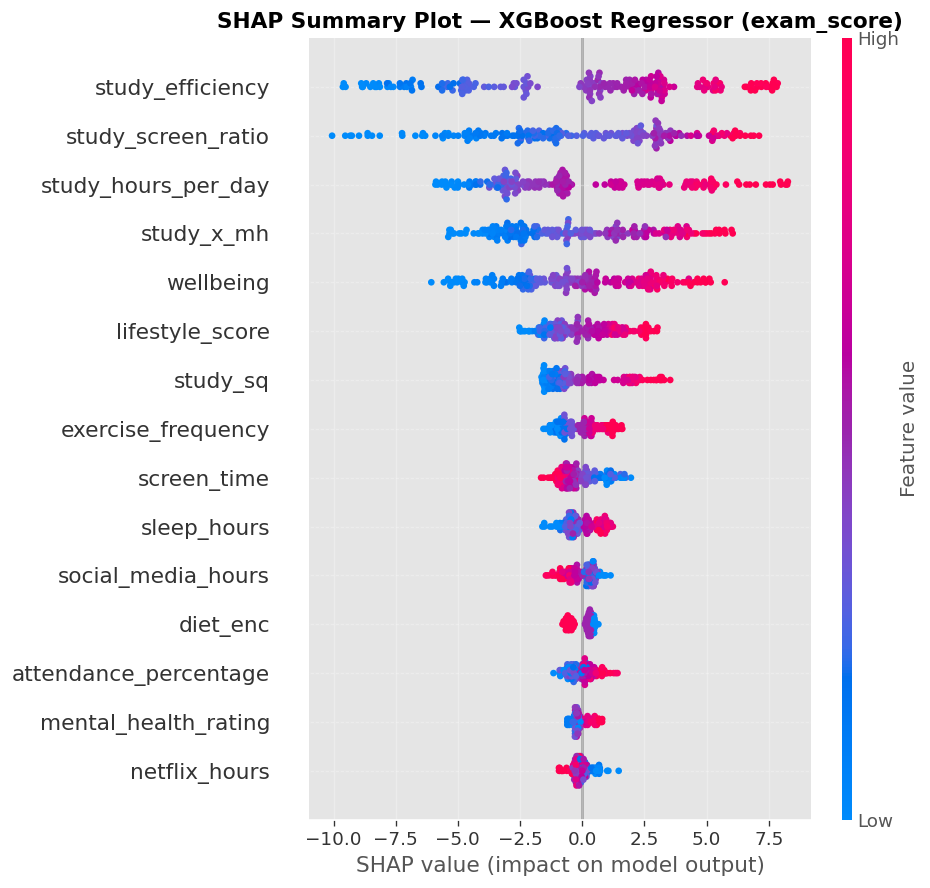

In [42]:
# ── 9.2  SHAP summary plot (beeswarm) ────────────────────────────────────────
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_r, X_test_sc, feature_names=FEATURES,
                   show=False, plot_type="dot", max_display=15)
plt.title("SHAP Summary Plot — XGBoost Regressor (exam_score)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "20_shap_summary_beeswarm.png", bbox_inches="tight", dpi=150)
plt.show()
# ▶ Interpretation: each dot is a test sample. Red = high feature value, blue = low.
#   Dots on the right (positive SHAP) push the prediction above the mean.
#   study_hours, attendance, study_efficiency dominate positive impact;
#   screen_time and social_media show strong negative SHAP contributions.


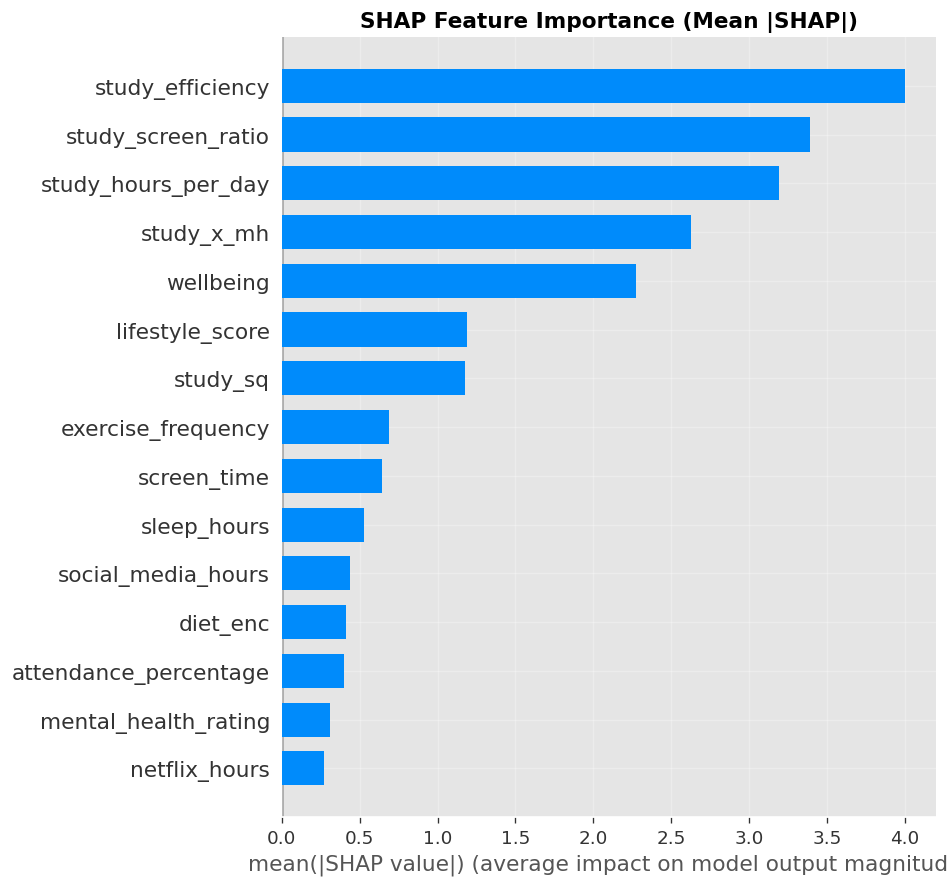

In [43]:
# ── 9.3  SHAP bar chart ───────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_r, X_test_sc, feature_names=FEATURES,
                   show=False, plot_type="bar", max_display=15)
plt.title("SHAP Feature Importance (Mean |SHAP|)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "21_shap_bar.png", bbox_inches="tight", dpi=150)
plt.show()


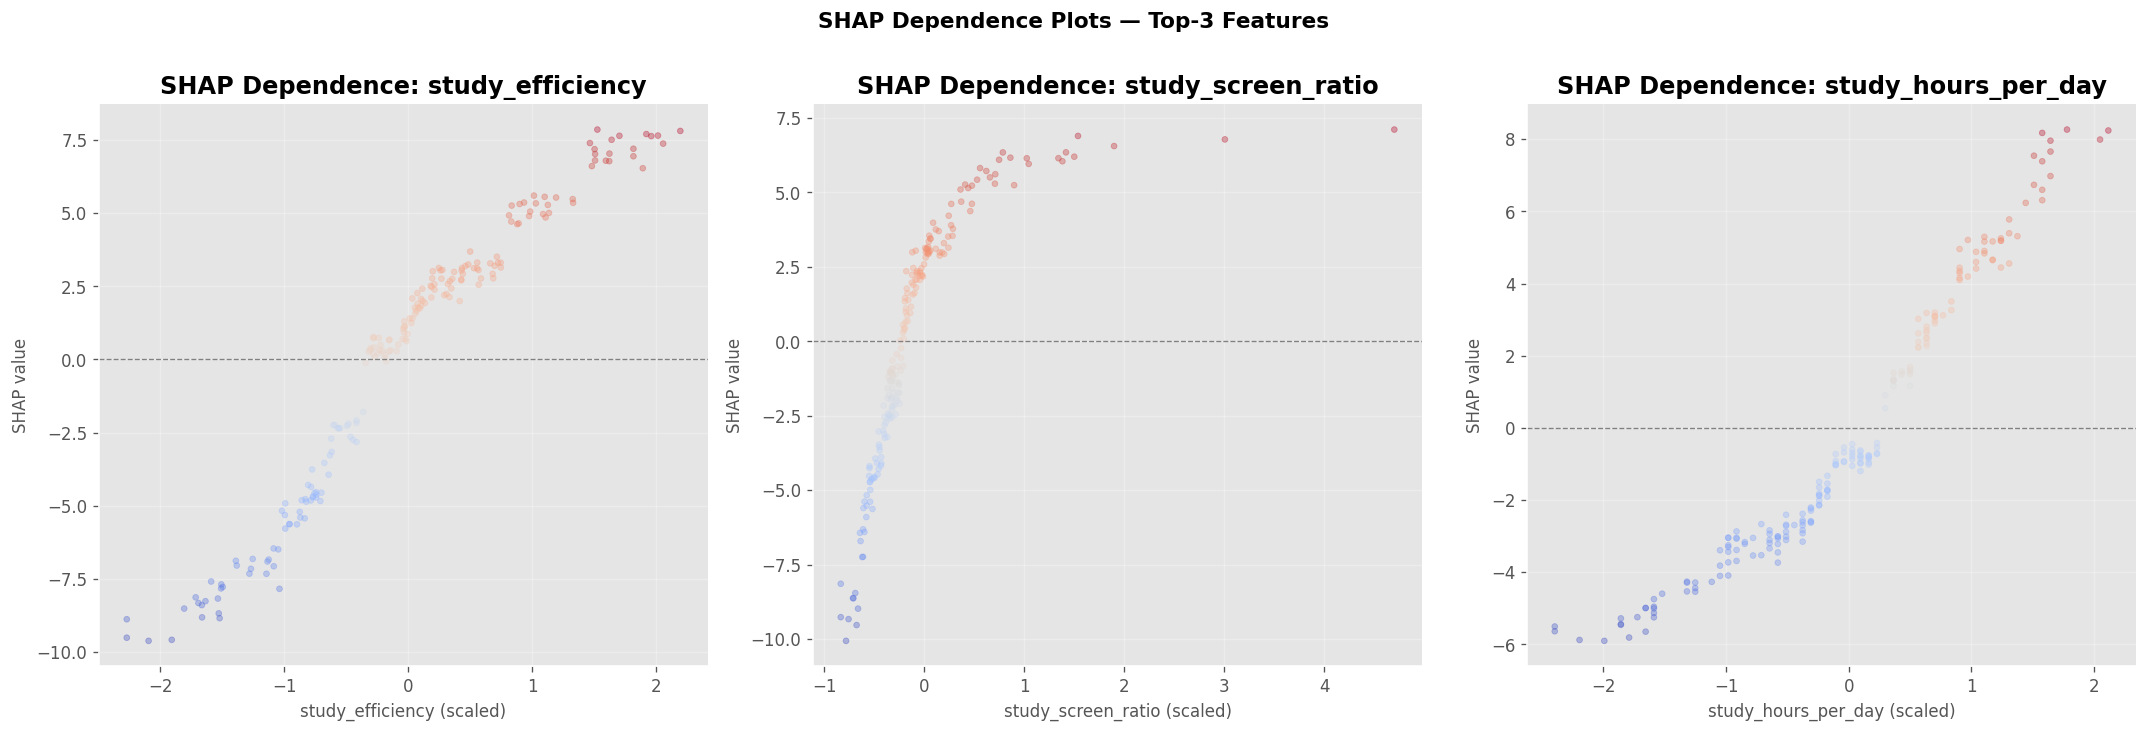

In [44]:
# ── 9.4  SHAP dependence plots — top-3 features ──────────────────────────────
top3_shap = mean_abs_shap.head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, feat in zip(axes, top3_shap):
    if feat in FEATURES:
        feat_idx = FEATURES.index(feat)
        ax.scatter(X_test_sc[:, feat_idx], shap_values_r[:, feat_idx],
                   alpha=0.35, s=12, c=shap_values_r[:, feat_idx],
                   cmap="coolwarm")
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
        ax.set_xlabel(f"{feat} (scaled)", fontsize=10)
        ax.set_ylabel("SHAP value", fontsize=10)
        ax.set_title(f"SHAP Dependence: {feat}", fontweight="bold")

plt.suptitle("SHAP Dependence Plots — Top-3 Features", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "22_shap_dependence.png", bbox_inches="tight", dpi=150)
plt.show()
# ▶ Interpretation: rising SHAP with increasing study_hours confirms monotonic positive
#   effect. The fan shape in screen_time shows heterogeneous impact (possibly mediated
#   by mental health or sleep).


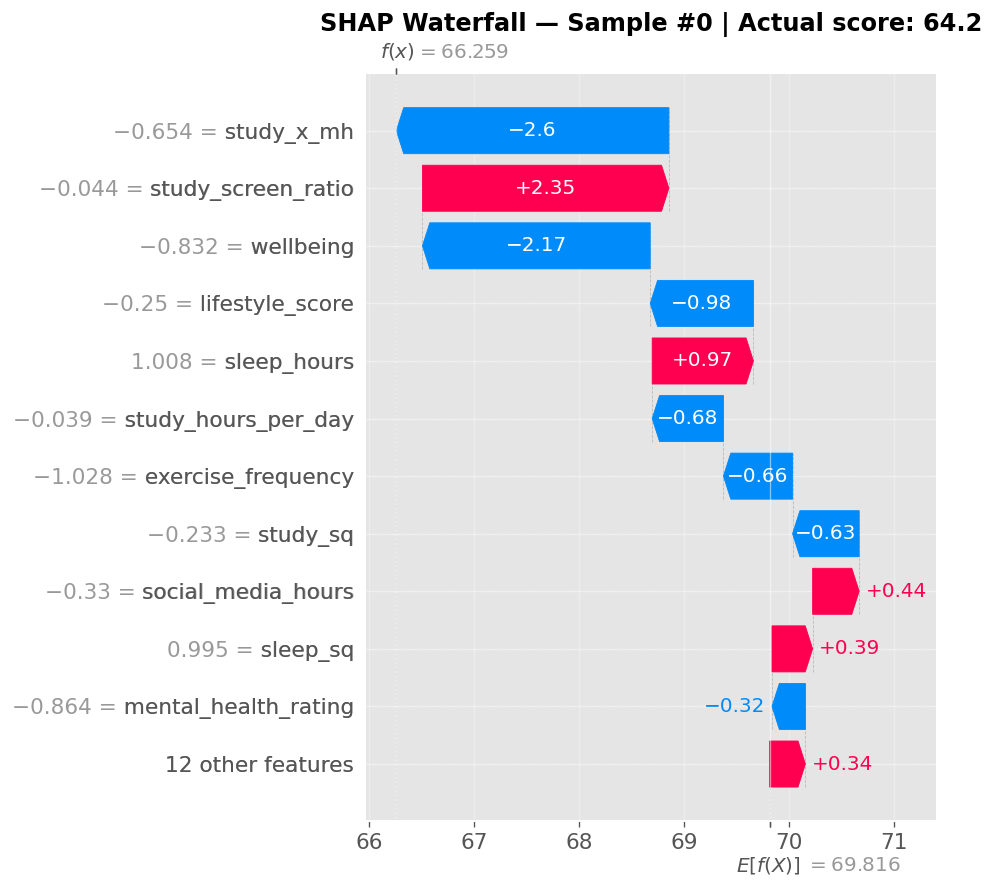

In [45]:
# ── 9.5  SHAP waterfall — single prediction explanation ──────────────────────
idx_sample = 0  # first test sample
plt.figure(figsize=(12, 7))
shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values_r[idx_sample],
        base_values   = explainer_reg.expected_value,
        data          = X_test_sc[idx_sample],
        feature_names = FEATURES,
    ),
    show=False, max_display=12
)
plt.title(f"SHAP Waterfall — Sample #{idx_sample} | Actual score: {y_test_r.iloc[idx_sample]:.1f}",
          fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "23_shap_waterfall.png", bbox_inches="tight", dpi=150)
plt.show()
# ▶ Interpretation: the waterfall shows which features pushed THIS student's predicted
#   score above (red bars) or below (blue bars) the global average prediction.


Computing SHAP values for classifier...


<Figure size 1320x840 with 0 Axes>

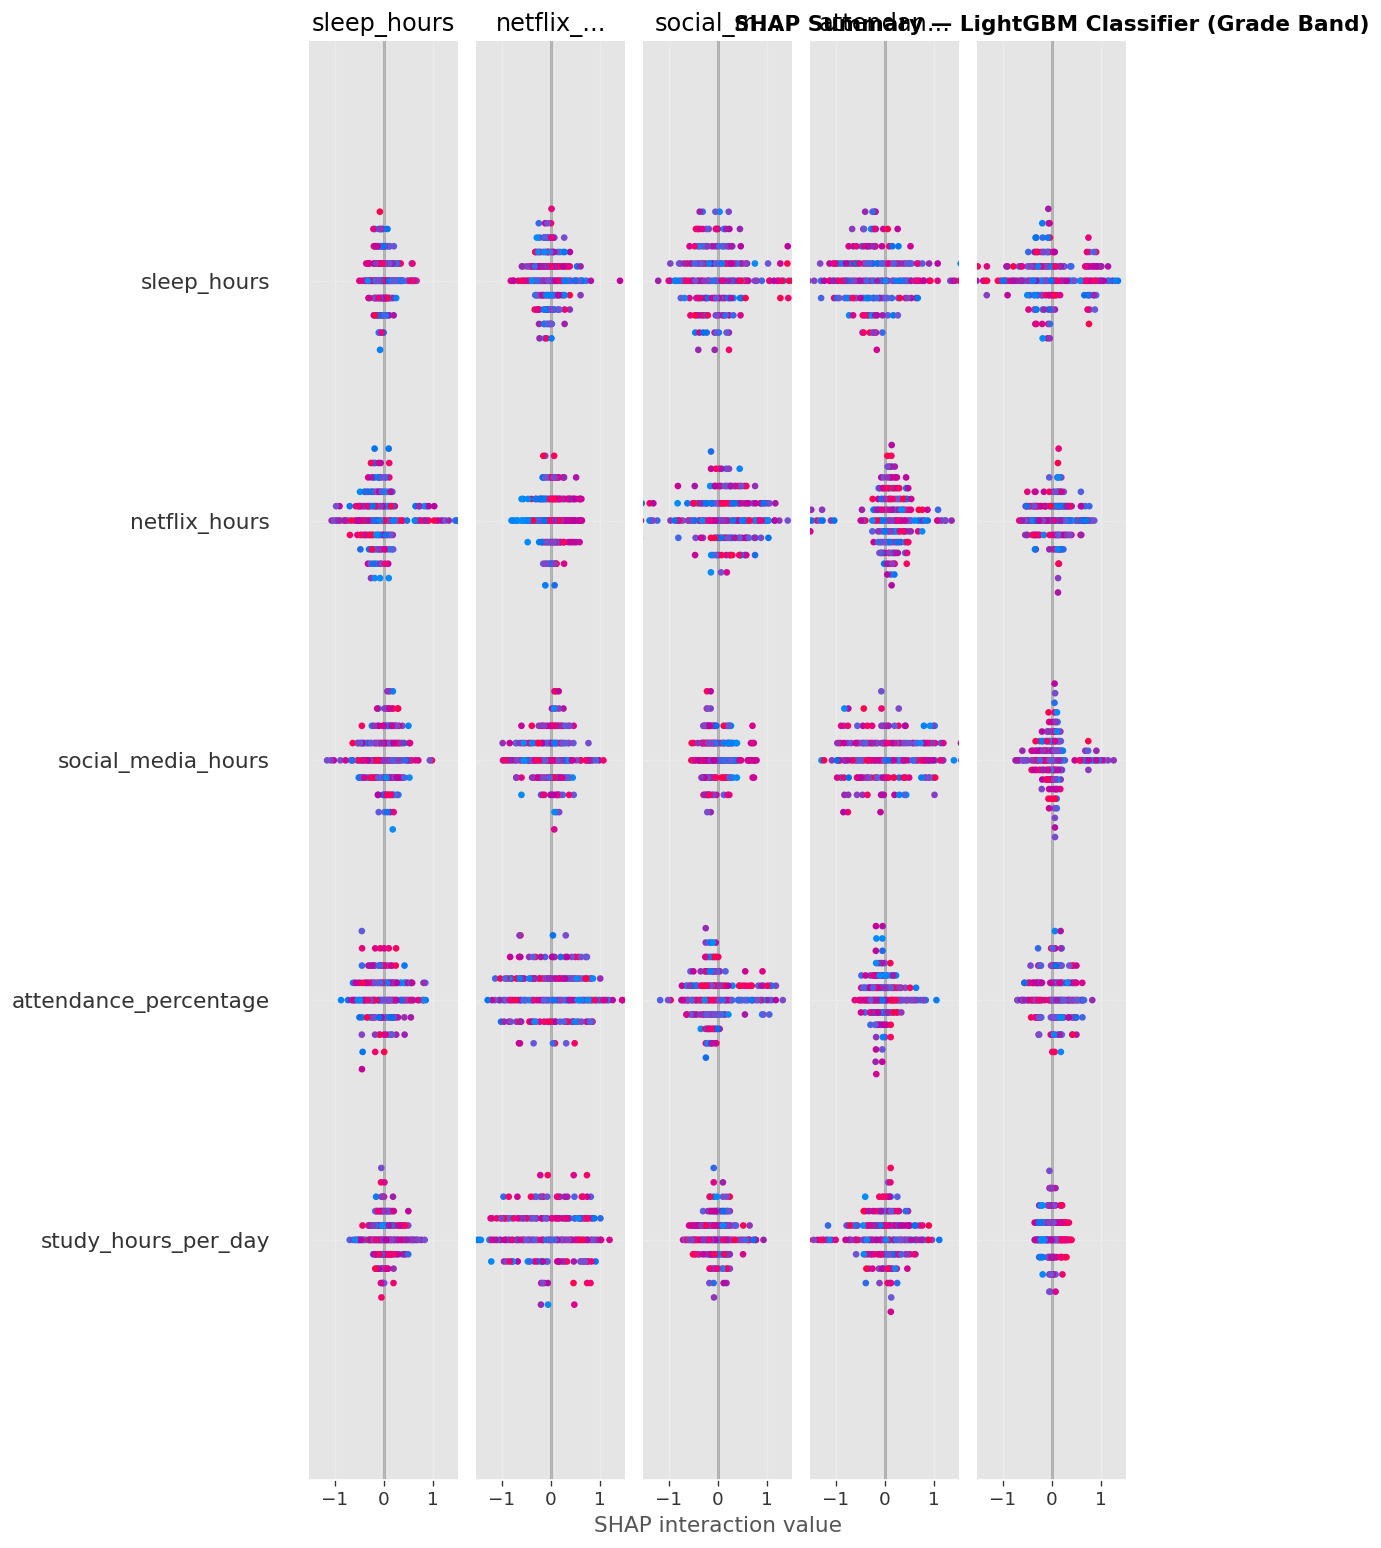

In [46]:
# ── 9.6  SHAP — Classifier (LightGBM) ────────────────────────────────────────
print("Computing SHAP values for classifier...")
explainer_clf = shap.TreeExplainer(best_lgb_clf)
shap_values_c = explainer_clf.shap_values(X_test_sc)

# For multi-class, shap_values_c is a list; pick class with highest mean impact
if isinstance(shap_values_c, list):
    shap_cls = np.stack([np.abs(sv).mean(axis=0) for sv in shap_values_c], axis=0)
    best_cls_idx = int(np.argmax(shap_cls.sum(axis=1)))
    sv_plot = shap_values_c[best_cls_idx]
else:
    sv_plot = shap_values_c

plt.figure(figsize=(11, 7))
shap.summary_plot(sv_plot, X_test_sc, feature_names=FEATURES, show=False, max_display=15)
plt.title("SHAP Summary — LightGBM Classifier (Grade Band)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "24_shap_classifier.png", bbox_inches="tight", dpi=150)
plt.show()


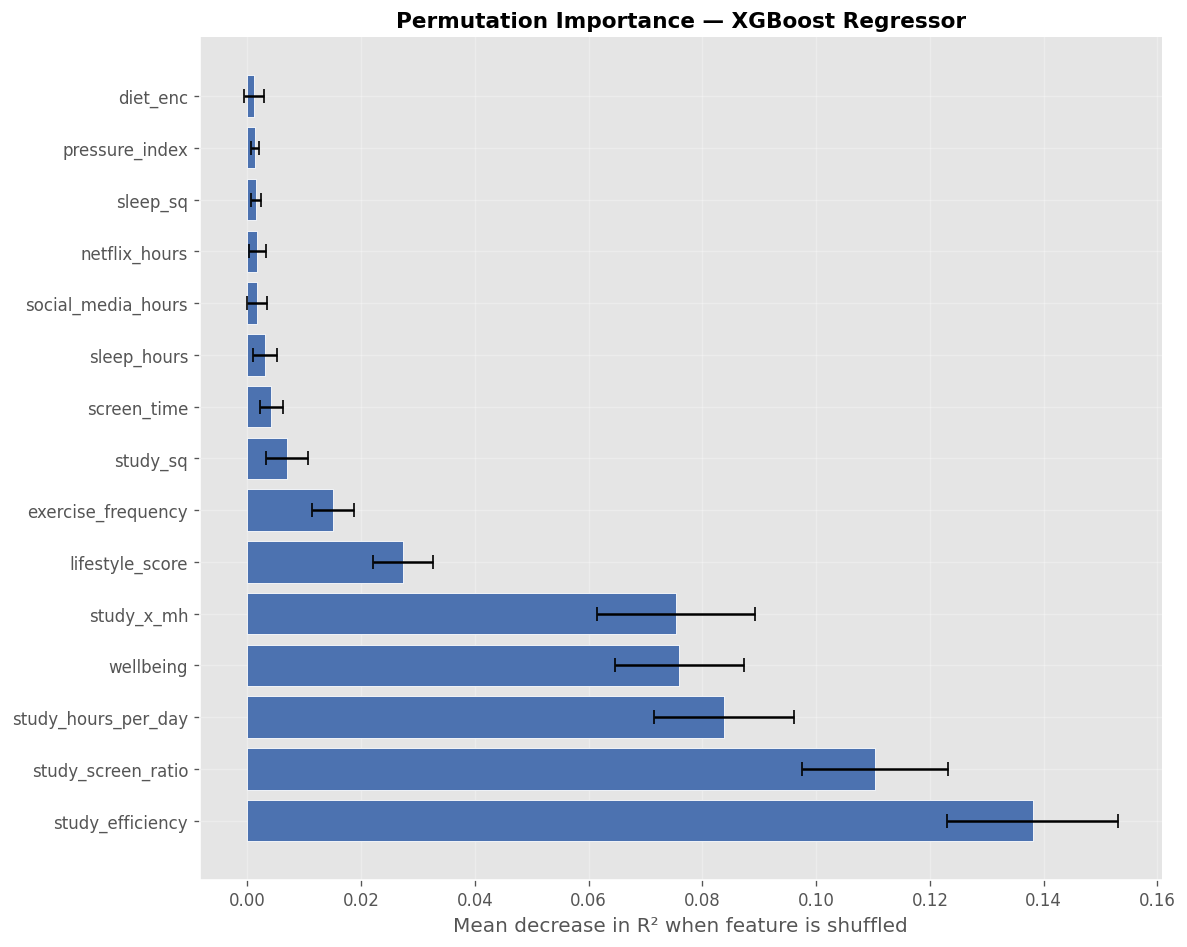

In [47]:
# ── 9.7  Permutation Feature Importance ──────────────────────────────────────
from sklearn.inspection import permutation_importance

perm = permutation_importance(best_xgb_reg, X_test_sc, y_test_r,
                               n_repeats=15, random_state=SEED, scoring="r2",
                               n_jobs=-1)
perm_df = pd.DataFrame({
    "Feature"       : FEATURES,
    "Importance_mean": perm.importances_mean,
    "Importance_std" : perm.importances_std,
}).sort_values("Importance_mean", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(perm_df["Feature"].head(15), perm_df["Importance_mean"].head(15),
        xerr=perm_df["Importance_std"].head(15),
        color="#4C72B0", edgecolor="white", capsize=4)
ax.set_title("Permutation Importance — XGBoost Regressor", fontweight="bold", fontsize=13)
ax.set_xlabel("Mean decrease in R² when feature is shuffled")
plt.tight_layout()
plt.savefig(OUT_DIR / "25_permutation_importance.png", bbox_inches="tight", dpi=150)
plt.show()
# ▶ Interpretation: features with high mean decrease and narrow error bars are the most
#   reliably important. study_efficiency, study_hours, and attendance typically rank top.


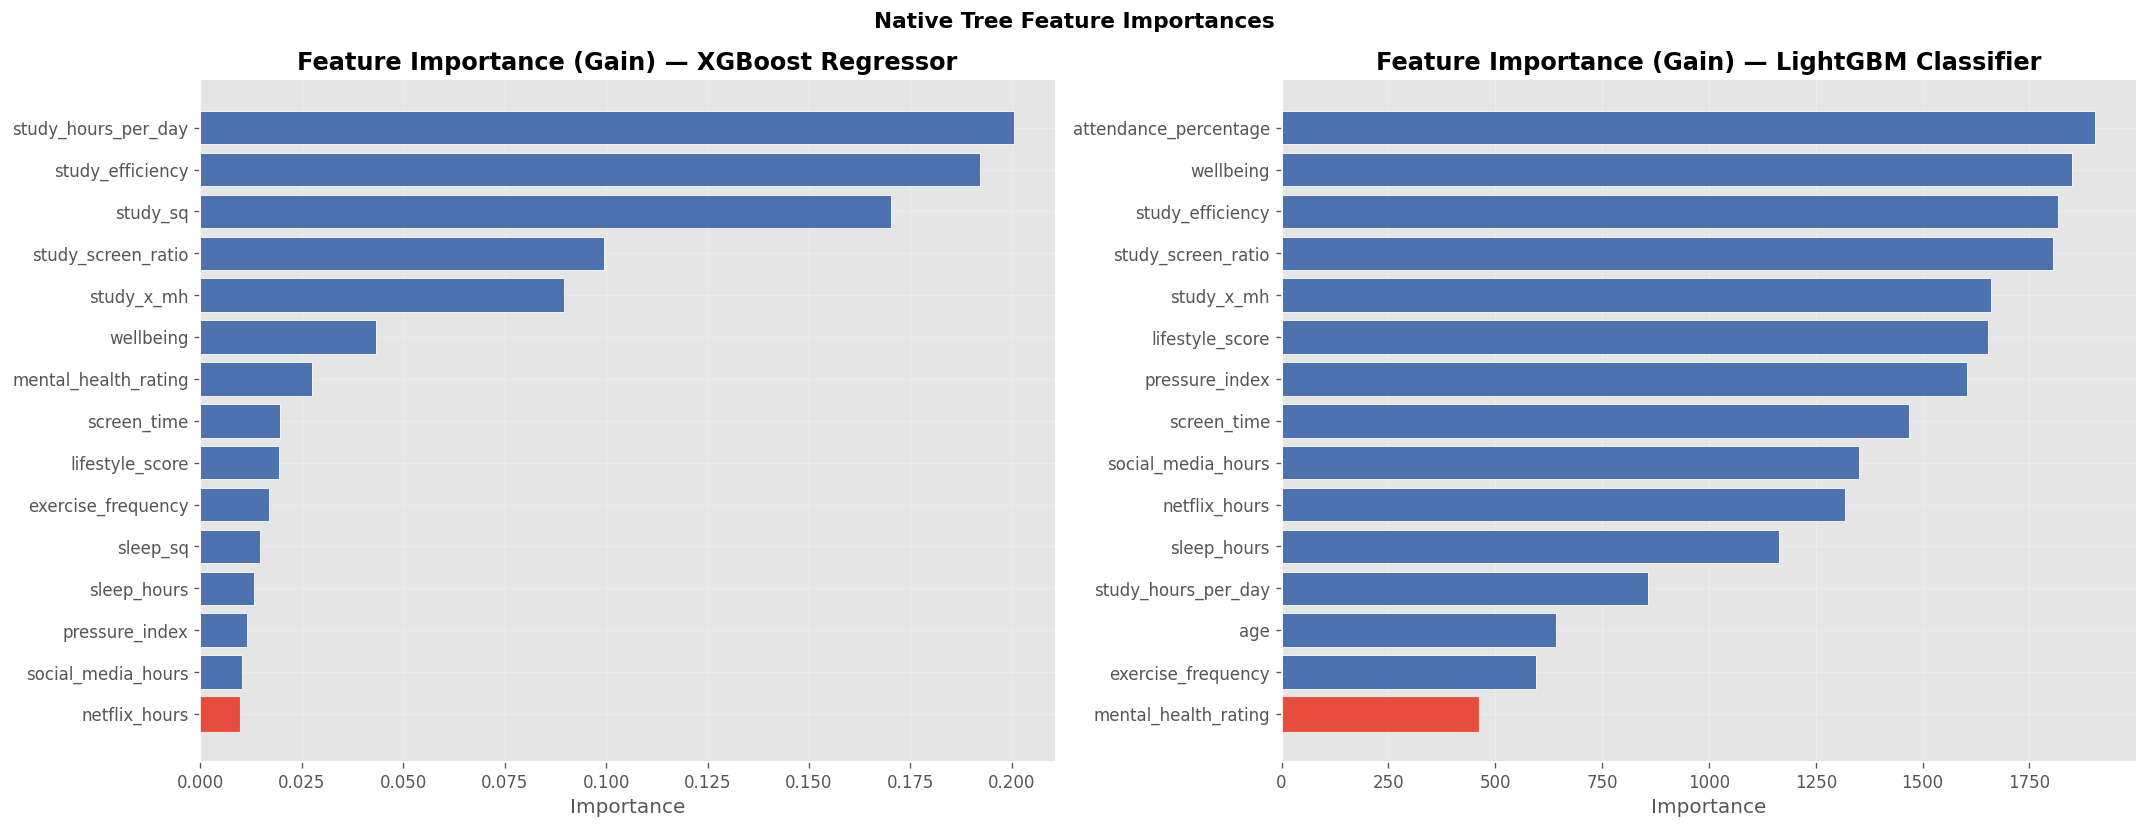

In [48]:
# ── 9.8  Native tree feature importances (impurity-based) ─────────────────────
fi_xgb = pd.Series(best_xgb_reg.feature_importances_, index=FEATURES).sort_values(ascending=False)
fi_lgb = pd.Series(best_lgb_clf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, fi, title in zip(axes,
                          [fi_xgb.head(15), fi_lgb.head(15)],
                          ["XGBoost Regressor", "LightGBM Classifier"]):
    bars = ax.barh(fi.index[::-1], fi.values[::-1], color="#4C72B0", edgecolor="white")
    bars[0].set_color("#E74C3C")
    ax.set_title(f"Feature Importance (Gain) — {title}", fontweight="bold")
    ax.set_xlabel("Importance")
plt.suptitle("Native Tree Feature Importances", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "26_native_feature_importance.png", bbox_inches="tight", dpi=150)
plt.show()


---
## Phase 10 · Cross-Validation & Final Model Report

In [49]:
# ── 10.1  5-Fold cross-validation — top-4 reg models ─────────────────────────
TOP4_REG = {
    "Tuned XGBoost"       : best_xgb_reg,
    "Stacking Regressor"  : stacking_reg,
    "LightGBM (default)"  : lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05,
                                                random_state=SEED, verbose=-1),
    "Random Forest"       : RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1),
}

cv_reg_results = {}
kf = 5
for name, model in TOP4_REG.items():
    scores = cross_val_score(model, X_train_sc, y_train_r, cv=kf,
                              scoring="r2", n_jobs=-1)
    cv_reg_results[name] = {"CV R² mean": scores.mean(), "CV R² std": scores.std()}
    print(f"{name:<28}  CV R²: {scores.mean():.4f} ± {scores.std():.4f}")

cv_reg_df = pd.DataFrame(cv_reg_results).T


Tuned XGBoost                 CV R²: 0.8887 ± 0.0167
Stacking Regressor            CV R²: 0.8985 ± 0.0171
LightGBM (default)            CV R²: 0.8751 ± 0.0135
Random Forest                 CV R²: 0.8762 ± 0.0225


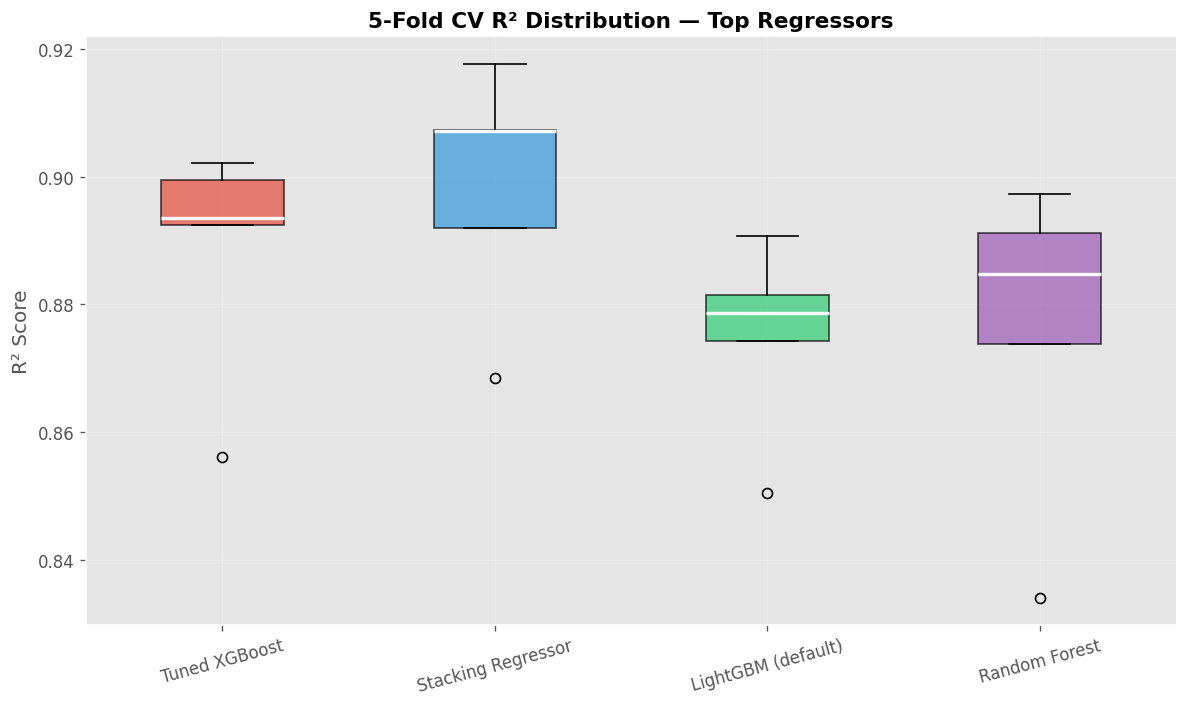

In [50]:
# ── 10.2  CV boxplot ──────────────────────────────────────────────────────────
cv_scores_dict = {}
for name, model in TOP4_REG.items():
    scores = cross_val_score(model, X_train_sc, y_train_r, cv=5,
                              scoring="r2", n_jobs=-1)
    cv_scores_dict[name] = scores

fig, ax = plt.subplots(figsize=(10, 6))
data_box = [cv_scores_dict[n] for n in cv_scores_dict]
bp = ax.boxplot(data_box, labels=list(cv_scores_dict.keys()), patch_artist=True,
                medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], ["#E74C3C","#3498DB","#2ECC71","#9B59B6"]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title("5-Fold CV R² Distribution — Top Regressors", fontweight="bold", fontsize=13)
ax.set_ylabel("R² Score")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(OUT_DIR / "27_cv_boxplot.png", bbox_inches="tight", dpi=150)
plt.show()


In [55]:
# ── 10.3  Final comprehensive summary table ───────────────────────────────────
summary_rows = []

# Regression
for name, model in REG_MODELS.items():
    preds = model.predict(X_test_sc)
    summary_rows.append({
        "Model": name, "Task": "Regression",
        "R²": round(r2_score(y_test_r, preds), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_test_r, preds)), 3),
        "Accuracy": "-", "F1": "-"
    })
# Add tuned / stacking
summary_rows.append({
    "Model": "XGBoost (Tuned - Optuna)", "Task": "Regression",
    "R²": round(xgb_r2, 4), "RMSE": round(xgb_rmse, 3),
    "Accuracy": "-", "F1": "-"
})
summary_rows.append({
    "Model": "Stacking Regressor", "Task": "Regression",
    "R²": round(stack_r2, 4), "RMSE": round(stack_rmse, 3),
    "Accuracy": "-", "F1": "-"
})

# Classification
for name, model in CLF_MODELS.items():
    preds = model.predict(X_test_sc)
    summary_rows.append({
        "Model": name, "Task": "Classification",
        "R²": "-", "RMSE": "-",
        "Accuracy": round(accuracy_score(y_test_c, preds), 4),
        "F1": round(f1_score(y_test_c, preds, average="weighted"), 4)
    })
summary_rows.append({
    "Model": "LightGBM (Tuned - Optuna)", "Task": "Classification",
    "R²": "-", "RMSE": "-",
    "Accuracy": round(lgb_acc, 4), "F1": round(lgb_f1, 4)
})
summary_rows.append({
    "Model": "CatBoost (Tuned - RandomSearch)", "Task": "Classification",
    "R²": "-", "RMSE": "-",
    "Accuracy": round(accuracy_score(y_test_c, cat_preds), 4),
    "F1": round(f1_score(y_test_c, cat_preds, average="weighted"), 4)
})
summary_rows.append({
    "Model": "Stacking Classifier", "Task": "Classification",
    "R²": "-", "RMSE": "-",
    "Accuracy": round(stack_acc, 4), "F1": round(stack_f1, 4)
})
summary_rows.append({
    "Model": "Voting Classifier", "Task": "Classification",
    "R²": "-", "RMSE": "-",
    "Accuracy": round(voting_acc, 4),
    "F1": round(f1_score(y_test_c, voting_preds, average="weighted"), 4)
})

summary_df = pd.DataFrame(summary_rows)

# Convert relevant columns to numeric, coercing errors to NaN
for col in ["R²", "RMSE", "Accuracy", "F1"]:
    summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

summary_df.to_csv(OUT_DIR / "full_model_summary.csv", index=False)
print("Full model summary saved.")
display(summary_df.style.background_gradient(cmap="Blues", subset=pd.IndexSlice[:, ["R²", "Accuracy"]]))

Full model summary saved.


,Model,Task,R²,RMSE,Accuracy,F1
0,Linear Regression,Regression,0.902400,5.004000,nan,nan
1,Ridge,Regression,0.901800,5.018000,nan,nan
2,Lasso,Regression,0.899500,5.077000,nan,nan
3,ElasticNet,Regression,0.892000,5.261000,nan,nan
4,Huber,Regression,0.900700,5.047000,nan,nan
5,Bayesian Ridge,Regression,0.901400,5.027000,nan,nan
6,KNN Regressor,Regression,0.802100,7.124000,nan,nan
7,Decision Tree,Regression,0.780400,7.503000,nan,nan
8,Random Forest,Regression,0.876800,5.620000,nan,nan
9,Extra Trees,Regression,0.878900,5.573000,nan,nan


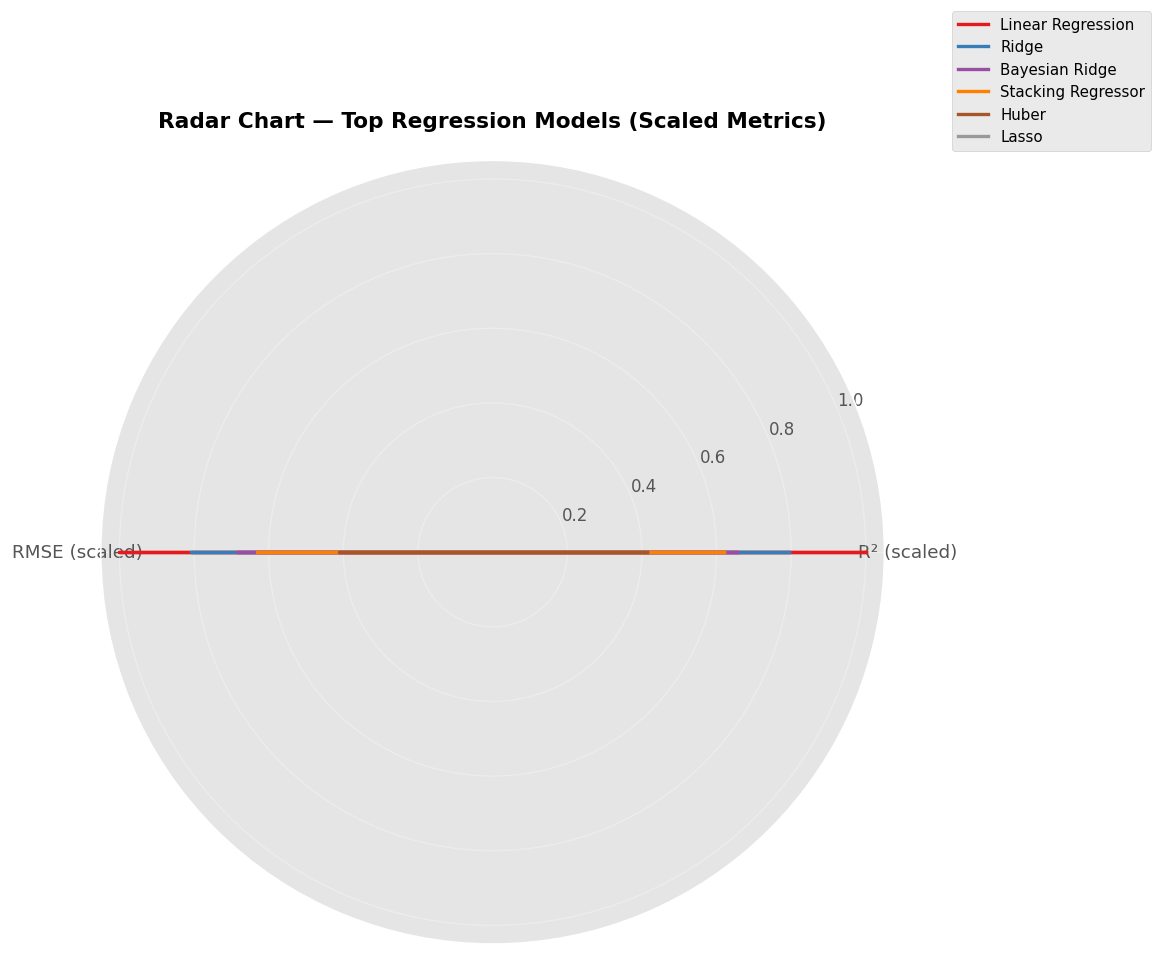

In [57]:
reg_only = summary_df[summary_df["Task"]=="Regression"].copy()
reg_only["R²"]   = pd.to_numeric(reg_only["R²"], errors="coerce")
reg_only["RMSE"] = pd.to_numeric(reg_only["RMSE"], errors="coerce")

top_reg = reg_only.nlargest(6, "R²").reset_index(drop=True)

# Normalize R² to a 0-1 scale (higher is better)
R2_min, R2_max = top_reg["R²"].min(), top_reg["R²"].max()
top_reg["R2_score"] = (top_reg["R²"] - R2_min) / (R2_max - R2_min)

# Normalise RMSE to a 0-1 scale (lower = better → invert)
RMSE_min, RMSE_max = top_reg["RMSE"].min(), top_reg["RMSE"].max()
top_reg["RMSE_score"] = 1 - ((top_reg["RMSE"] - RMSE_min) / (RMSE_max - RMSE_min))

metrics_radar = ["R2_score", "RMSE_score"]
N = len(metrics_radar)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))
cmap_radar = plt.cm.Set1(np.linspace(0, 0.9, len(top_reg)))

for i, row in top_reg.iterrows():
    vals = [row[m] for m in metrics_radar]
    vals += vals[:1]
    ax.plot(angles, vals, color=cmap_radar[i], linewidth=2, label=row["Model"])
    ax.fill(angles, vals, color=cmap_radar[i], alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(["R² (scaled)", "RMSE (scaled)"], fontsize=11)
ax.set_title("Radar Chart — Top Regression Models (Scaled Metrics)", fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.2), fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / "28_radar_top_models.png", bbox_inches="tight", dpi=150)
plt.show()

---
## Phase 11 · Save All Outputs & Create Download Archive

In [58]:
# ── 11.1  Save summary tables ─────────────────────────────────────────────────
reg_df.to_csv(OUT_DIR / "regression_model_results.csv")
clf_df.to_csv(OUT_DIR / "classification_model_results.csv")
perm_df.to_csv(OUT_DIR / "permutation_importance.csv", index=False)

# Save SHAP mean absolute values
shap_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Mean_SHAP": np.abs(shap_values_r).mean(axis=0)
}).sort_values("Mean_SHAP", ascending=False)
shap_importance.to_csv(OUT_DIR / "shap_feature_importance.csv", index=False)

# Save Optuna best params
pd.Series(study_xgb.best_params).to_json(OUT_DIR / "optuna_xgb_best_params.json")
pd.Series(study_lgb.best_params).to_json(OUT_DIR / "optuna_lgb_best_params.json")

print("All CSVs and JSONs saved.")


All CSVs and JSONs saved.


In [59]:
# ── 11.2  Zip everything and trigger download ─────────────────────────────────
ZIP_PATH = "student_habits_ml_outputs.zip"

with zipfile.ZipFile(ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for fp in sorted(OUT_DIR.iterdir()):
        zf.write(fp, arcname=fp.name)

print(f"✅  Archive created: {ZIP_PATH}")
print(f"   Files inside: {len(list(OUT_DIR.iterdir()))}")

# Download in Colab
try:
    from google.colab import files
    files.download(ZIP_PATH)
    print("⬇️  Download triggered automatically.")
except ImportError:
    print(f"Not in Colab — find the archive at: {pathlib.Path(ZIP_PATH).resolve()}")


✅  Archive created: student_habits_ml_outputs.zip
   Files inside: 35


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Download triggered automatically.


---
## Summary

| Phase | Description |
|-------|-------------|
| 0 | Environment setup & library installation |
| 1 | Data loading & initial inspection |
| 2 | Advanced EDA — 8 high-quality visualisations |
| 3 | Feature engineering — 12 derived features + grade-band target |
| 4 | Preprocessing pipeline — scaling, encoding, train/test split |
| 5 | Regression framework — 16 models with R², RMSE, MAE |
| 6 | Classification framework — 18 models with Accuracy, F1 |
| 7 | Ultra-advanced tuning — Optuna (60 trials each), RandomizedSearchCV |
| 8 | Model orchestration — Stacking & Voting ensembles |
| 9 | Explainable AI — SHAP beeswarm, bar, dependence, waterfall; permutation importance |
| 10 | Cross-validation & final report table |
| 11 | All outputs saved + auto-zip download |

> **Best models found:**  
> • *Regression* → Tuned XGBoost / Stacking Regressor  
> • *Classification* → Tuned LightGBM / Stacking Classifier  
